**Домашнее задание №7**

**Цель:** Улучшение моедели и метрик

**Что сделано:**

* **Ячейка 3 — Feature engineering:** создано 87 безопасных новых признаков.
* **Ячейка 3 — Feature engineering:** добавлены family-признаки для планов охлаждения PM и кодов УЛО.
* **Ячейка 3 — Feature engineering:** добавлены средние технологические признаки за предыдущий календарный день `mean_yest_*`.
* **Ячейка 3 — Feature engineering:** добавлены признаки скорости и технологического режима `ind_speed_vol_20` и `f_speed_thread_gap`.

* **Ячейка 9 — Улучшенный CatBoost:** выполнен train-only feature selection по важностям базового CatBoost.
* **Ячейка 9 — Улучшенный CatBoost:** выполнен ручной grid search параметров CatBoost только внутри TRAIN.
* **Ячейка 9 — Улучшенный CatBoost:** после отбора признаков повторно обучен CatBoost на сокращённом наборе признаков.
* **Ячейка 9.1 — Optuna CatBoost:** добавлен отдельный эксперимент с автоматическим подбором параметров CatBoost.

* **Ячейка 10 — Оценка моделей:** выполнено сравнение baseline, простых моделей, базового CatBoost, CatBoost с feature selection и Optuna.

* **Ячейка 11 — Пороги:** добавлены три стратегии выбора порога: `precision_first`, `balanced` и `recall_first`.

* **Ячейка 12 — Дневной и недельный прогноз:** добавлена изотоническая калибровка вероятностей на VALIDATION.
* **Ячейка 12 — Дневной и недельный прогноз:** сформирован прогноз процента дефекта по дням и неделям.

* **Ячейка 13 — Продуктовые метрики:** рассчитаны MAE, RMSE, BIAS, WMAE, WRMSE, WBIAS и корреляция.

* **Ячейка 14 — Анализ ошибок:** добавлен анализ худших дней, ошибок TP / FP / FN / TN и производственных сегментов.
* **Ячейка 14 — Анализ ошибок:** добавлена проверка drift между PRETEST и HOLDOUT.

* **Ячейка 15 — Time-series эксперимент:** добавлены lag, rolling, delta и z-score признаки по прошлым наблюдениям.
* **Ячейка 15 — Time-series эксперимент:** выполнено отдельное сравнение time-series CatBoost с базовыми CatBoost-моделями.

* **Ячейка 16 — Финальный вывод:** собраны row-level и продуктовые метрики на VALIDATION, PRETEST и HOLDOUT.


**ВОПРОСЫ**

Для прогноза дневного и недельного процента дефекта я калибрую вероятности на VALIDATION через Isotonic Regression. Достаточно ли такой схемы, или правильнее строить OOF-калибровку внутри TRAIN и оставить VALIDATION только для выбора финального решения?

**Решение:** нежелательно на одной выборке делать и калибровку и порог 

**ИСПРАВИЛ** 

Теперь схема такая:

**TRAIN:**
    временные OOF-фолды
    → OOF-прогнозы
    → обучение Isotonic Regression

**VALIDATION:**
    выбор модели и порога
    → не используется для fit калибратора

**PRETEST:**
    внешняя промежуточная проверка

**HOLDOUT:**
    финальная проверка

In [ ]:
# Подготовка и загрузка библиотек

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.isotonic import IsotonicRegression

from catboost import CatBoostClassifier

import optuna

# Фиксирую random state, чтобы результаты обучения и экспериментов можно было воспроизвести
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # Отдельно фиксирую генератор случайных чисел NumPy

DATA_PATH = "data.csv"

# Здесь задаю основные колонки, которые дальше использую во всем ноутбуке
TIME_COL = "Дата-время производства"
TARGET_COL = "Карантины ПК | Неплоскостность | Стан 2000 | После стана"

# Все данные после этой даты оставляю как финальный HOLDOUT
HOLDOUT_START = pd.Timestamp("2026-02-28 23:04:31")

# Задаю основные настройки оценки модели и отбора признаков
TOP_K_SHARE = 0.10          # Анализирую верхние 10% объектов с максимальным риском
TOP_SELECTED_FEATURES = 65  # Оставляю 65 наиболее важных признаков для feature selection

# Для пропусков в категориальных признаках использую одно специальное строковое значение
NA_TOKEN = "__NA__"


def print_title(text):
    print("\n" + "=" * 120)
    print(text)
    print("=" * 120)

In [2]:
print_title("1. Загрузка данных")


df = pd.read_parquet(DATA_PATH)

# Сначала убираю лишние пробелы из названий колонок, чтобы дальше стабильно обращаться к ним
df.columns = [str(c).strip() for c in df.columns]

# После merge колонка времени могла получить суффикс "_y", поэтому возвращаю исходное название
if TIME_COL not in df.columns and f"{TIME_COL}_y" in df.columns:
    df = df.rename(columns={f"{TIME_COL}_y": TIME_COL})

# Сразу останавливаю выполнение, если основной временной признак не найден
if TIME_COL not in df.columns:
    raise ValueError(f"Не найдена колонка времени: {TIME_COL}")

# До дальнейшей обработки отдельно проверяю наличие целевой колонки
if TARGET_COL not in df.columns:
    raise ValueError(f"Не найдена колонка таргета: {TARGET_COL}")

# Привожу время к единому datetime-формату, а некорректные значения перевожу в NaT
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

print("Размер:", df.shape)
print("Дата min:", df[TIME_COL].min())
print("Дата max:", df[TIME_COL].max())
print("Таргет:", TARGET_COL)


1. Загрузка данных
Размер: (24324, 1966)
Дата min: 2025-06-01 02:29:15
Дата max: 2026-03-31 22:12:43
Таргет: Карантины ПК | Неплоскостность | Стан 2000 | После стана


In [3]:
print_title("2. Таргет")

df_work = df.copy()

# Удаляю строки без корректной даты, так как их нельзя использовать во временном разделении
df_work = df_work[df_work[TIME_COL].notna()].copy()

# Формирую бинарный таргет: наличие записи о карантине считаю дефектом
y_all = df_work[TARGET_COL].notna().astype("int8")  # 1 — дефект, 0 — дефекта нет

# Проверяю размер выборки и баланс классов после фильтрации
print("Размер после фильтров:", df_work.shape)
print("Дефектов:", int(y_all.sum()))  # Смотрю количество объектов положительного класса
print("Доля дефекта:", round(float(y_all.mean() * 100), 3), "%")  # Считаю долю класса 1 в процентах

display(pd.DataFrame({
    "class": ["0 = нет дефекта", "1 = дефект"],
    "count": [(y_all == 0).sum(), (y_all == 1).sum()],  # Считаю абсолютное число строк каждого класса
    "share": [(y_all == 0).mean(), (y_all == 1).mean()],  # Считаю долю каждого класса от всей выборки
}))


2. Таргет
Размер после фильтров: (24324, 1966)
Дефектов: 1750
Доля дефекта: 7.195 %


,class,count,share
0,0 = нет дефекта,22574,0.928055
1,1 = дефект,1750,0.071945


In [4]:
print_title("3. Feature engineering")


# Сначала нормализую текстовые признаки:
# привожу значения к строкам, убираю лишние пробелы и возвращаю текстовые пропуски в np.nan
def norm_obj(s):
    return (
        s.astype("object")  # Сначала привожу колонку к универсальному object-типу
        .where(~s.isna(), np.nan)  # Сохраняю настоящие пропуски как np.nan
        .astype(str)  # Остальные значения привожу к строкам для дальнейшей очистки
        .str.replace("\xa0", " ", regex=False)  # Неразрывные пробелы заменяю обычными
        .str.strip()  # Убираю пробелы в начале и конце строки
        .replace({"": np.nan, "nan": np.nan, "None": np.nan, "<NA>": np.nan})  # Строковые пропуски снова перевожу в np.nan
    )


# Из длинного составного кода оставляю первые n частей.
# Так я уменьшаю редкость категорий и объединяю близкие технологические варианты в общие семейства.
def family_tokens(s, n=6):
    x = norm_obj(s)  # Сначала очищаю исходные текстовые значения
    return x.apply(
        lambda v: ".".join(str(v).split(".")[:n]) if pd.notna(v) else np.nan
    )  # Оставляю первые 6 частей кода, разделённых точкой


# Текстовое требование по плоскостности разбираю на два признака:
# унифицированную категорию и отдельное числовое значение в мм/м
def parse_flatness_req(x):
    # Для пропуска возвращаю отдельную категорию и пустое числовое значение
    if pd.isna(x):
        return ("NA", np.nan)

    # Перед поиском значений привожу текст к единому виду
    s = str(x).lower().replace(",", ".")  # Использую нижний регистр и единый десятичный разделитель
    s = re.sub(r"\s+", " ", s)  # Несколько пробелов подряд заменяю одним

    # Иногда в колонке указано только требование улучшенной плоскостности без числа
    if "улучш" in s and not re.search(r"\d", s):
        return ("УЛУЧШЕННАЯ_ПЛОСКОСТНОСТЬ", np.nan)

    # Сначала ищу полноценную запись вида "2 мм/м", "2.5 мм / м" и похожие варианты
    m = re.search(r"(\d+(?:\.\d+)?)\s*мм\s*/?\s*м", s)
    if m:
        val = float(m.group(1))  # Извлекаю найденное числовое ограничение
        return (f"<= {val:g} мм/м", val)  # Возвращаю категорию и числовое значение

    # Если единиц измерения нет, но число присутствует, сохраняю его как отдельную категорию
    m = re.search(r"(\d+(?:\.\d+)?)", s)
    if m:
        return (f"ЧИСЛО_{float(m.group(1)):g}", np.nan)

    # Все остальные нестандартные записи объединяю в одну категорию
    return ("ДРУГОЕ", np.nan)


# В этом списке сохраняю названия всех новых признаков, чтобы затем проверить результат
created_features = []


# Создаю укрупнённое семейство заданного плана охлаждения
if "Заданный план охлаждения (PM)" in df_work.columns:
    df_work["f_pm_family_6"] = family_tokens(
        df_work["Заданный план охлаждения (PM)"]
    )
    created_features.append("f_pm_family_6")


# Создаю семейство кода УЛО и отдельный индикатор отсутствующего значения
if "Код УЛО новый (ПЗ)" in df_work.columns:
    df_work["f_ulo_family_6"] = family_tokens(
        df_work["Код УЛО новый (ПЗ)"]
    )

    df_work["f_ulo_missing"] = (
        norm_obj(df_work["Код УЛО новый (ПЗ)"])
        .isna()
        .astype("int8")
    )  # Значение 1 означает, что код УЛО отсутствует

    created_features += ["f_ulo_family_6", "f_ulo_missing"]


# Разделяю текстовую колонку плоскостности на категориальную и числовую части
flat_col = "Величина плоскостности (СЗ)"

if flat_col in df_work.columns:
    parsed = df_work[flat_col].apply(parse_flatness_req)  # Для каждой строки получаю пару: категорию и число

    df_work[f"{flat_col}__unified"] = parsed.apply(
        lambda x: x[0]
    )  # Сохраняю унифицированное текстовое требование

    df_work[f"{flat_col}__mm_per_m"] = parsed.apply(
        lambda x: x[1]
    ).astype("float32")  # Сохраняю числовое ограничение в мм/м

    created_features += [
        f"{flat_col}__unified",
        f"{flat_col}__mm_per_m",
    ]


# Далее создаю признаки среднего значения показателей за предыдущий календарный день.
# Для текущего дня использую только данные прошлого дня, поэтому прямой утечки из будущего здесь нет.
def add_daily_lags(df_in, time_col, max_cols=80):
    df = df_in.copy() 

    day = df[time_col].dt.floor("D")  # Округляю время до начала календарного дня

    # Технологические признаки выбираю по основным префиксам
    prefixes = ("МСО", "СКН", "ЛПЦ-2", "мсо", "скн", "лпц-2")

    # Дополнительно добавляю важные технологические признаки,
    # которые не всегда попадают под выбранные префиксы
    extra_cols = [
        "Скорость смотки, сред",
        "Заправочная скорость смотки",
        "Скорость смотки, макс",
        "Общее время нагрева в печи_Зеленая, мин",
        "Скорость после чистовой группы_Зеленая, мин",
        "Ткп_Зеленая, мин",
        "Тсм_Зеленая, мин",
    ]

    # Формирую начальный список кандидатов для лаговых признаков
    candidate_cols = [
        c for c in df.columns
        if str(c).startswith(prefixes) or c in extra_cols
    ]

    # Исключаю признаки НТА-3 и НТА-4, так как они не относятся к нужному технологическому контуру
    bad_tokens = ("нта-3", "нта-4", "nta-3", "nta-4")

    candidate_cols = [
        c for c in candidate_cols
        if not any(t in str(c).lower() for t in bad_tokens)
    ]

    # Оставляю только признаки, которые действительно можно преобразовать в числа
    num_data = {}

    for c in candidate_cols:
        s = pd.to_numeric(df[c], errors="coerce")  # Некорректные строковые значения перевожу в NaN

        if s.notna().sum() > 0:
            num_data[c] = s.astype("float32")  # Использую float32, чтобы уменьшить потребление памяти

        if len(num_data) >= max_cols:
            break  # Ограничиваю количество лаговых признаков, чтобы не раздувать датасет

    # Если подходящих числовых признаков нет, возвращаю данные без изменений
    if len(num_data) == 0:
        return df, []

    # Собираю выбранные числовые признаки в отдельную таблицу
    tmp = pd.DataFrame(num_data, index=df.index)

    # Считаю среднее значение каждого признака по дням
    # и сдвигаю полученную таблицу на один день назад
    daily_mean_prev = (
        tmp.groupby(day)
        .mean()
        .sort_index()
        .shift(1)
    )  # В результате текущий день получает средние значения только предыдущего дня

    lag_features = {}

    # Возвращаю дневные значения обратно на уровень каждой отдельной строки
    for c in tmp.columns:
        lag_features[f"mean_yest_{c}"] = (
            day.map(daily_mean_prev[c])
            .astype("float32")
        )

    # Все новые лаговые признаки собираю одним DataFrame
    lag_df = pd.DataFrame(lag_features, index=df.index)

    # Добавляю новые признаки к исходным данным
    df = pd.concat([df, lag_df], axis=1)

    # Возвращаю обновлённые данные и список созданных колонок
    return df, list(lag_df.columns)


# Добавляю признаки средних технологических значений за предыдущий день
df_work, lag_cols = add_daily_lags(df_work, TIME_COL)

# Сохраняю их названия в общем списке новых признаков
created_features += lag_cols


# Задаю названия лаговых признаков, которые дальше использую для расчёта скорости и режима
speed_col = "mean_yest_Скорость смотки, сред"
thread_col = "mean_yest_Заправочная скорость смотки"


# Создаю показатель нестабильности средней скорости смотки
if speed_col in df_work.columns:
    s = pd.to_numeric(
        df_work[speed_col],
        errors="coerce",
    )

    # Получаю порядок строк строго по времени
    order = df_work[TIME_COL].sort_values(kind="mergesort").index

    # С помощью shift(1) исключаю текущую строку,
    # а rolling(20) считаю стандартное отклонение по 20 предыдущим наблюдениям
    roll = (
        s.loc[order]
        .shift(1)
        .rolling(20, min_periods=5)
        .std()
    )

    # Заранее создаю пустую колонку с экономным типом float32
    df_work["ind_speed_vol_20"] = pd.Series(
        index=df_work.index,
        dtype="float32",
    )

    # Возвращаю рассчитанные значения в исходные индексы
    df_work.loc[order, "ind_speed_vol_20"] = roll.values

    created_features.append("ind_speed_vol_20")


# Создаю относительную разницу между средней и заправочной скоростью смотки
if speed_col in df_work.columns and thread_col in df_work.columns:
    speed = pd.to_numeric(
        df_work[speed_col],
        errors="coerce",
    )

    thread = pd.to_numeric(
        df_work[thread_col],
        errors="coerce",
    )

    df_work["f_speed_thread_gap"] = (
        (speed - thread) / (speed.abs() + 1e-9)
    ).clip(-10, 10).astype("float32")
    # Добавляю 1e-9, чтобы защититься от деления на ноль
    # С помощью clip ограничиваю влияние аномально больших значений

    created_features.append("f_speed_thread_gap")


# В конце убираю возможные повторения и оставляю только реально созданные колонки
created_features = list(
    dict.fromkeys([
        c for c in created_features
        if c in df_work.columns
    ])
)


# Проверяю количество и состав новых признаков
print("Создано новых признаков:", len(created_features))

# Показываю первые 50 названий, чтобы не перегружать вывод
display(
    pd.DataFrame({
        "new_feature": created_features
    }).head(50)
)

# Проверяю итоговый размер данных после feature engineering
print("Размер после FE:", df_work.shape)


3. Feature engineering
Создано новых признаков: 87


,new_feature
0,f_pm_family_6
1,f_ulo_family_6
2,f_ulo_missing
3,Величина плоскостности (СЗ)__unified
4,Величина плоскостности (СЗ)__mm_per_m
5,mean_yest_СКН | лпц-2. % точек от 350 до 520 с...
6,mean_yest_СКН | лпц-2. ведущий пирометр при пр...
7,mean_yest_СКН | лпц-2. весь сортамент. расход ...
8,mean_yest_СКН | лпц-2. весь сортамент. расход ...
9,mean_yest_СКН | лпц-2. время нагрева в нагрева...


Размер после FE: (24324, 2053)


In [5]:
print_title("4. Удаление утечек и служебных колонок")


# Явный список колонок, которые нельзя использовать как признаки:
# сюда входят технические ID, фактические значения после производства,
# результаты других моделей и служебные поля.
# каждый признак обсуждался с руководством - подтверждена доступность признака или нет
DROP_EXACT = [
    # Технические индексы после сохранения файлов
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "Unnamed: 0.3",
    "Unnamed: 0.4",
    "Unnamed: 0.5",
    "Unnamed: 0.6",
    "Unnamed: 0.7",
    "Unnamed: 0.8",
    "Unnamed: 0.9",
    "Unnamed: 0.10",

    # Идентификаторы и номера объектов
    "ID Siemens",
    "ID УЕ MES",
    "ID ПЗ MES",
    "ID продукта",
    "ID продукта HRM",
    "ID продукта HRM_x",
    "ID продукта HRM_y",
    "ID планового заказа",
    "Маркировка УЕ",
    "Номер рулона",
    "Номер плавки",
    "Заказ",
    "Номер лота (СЗ)",

    # Даты и временные поля, недоступные на момент прогноза
    "Дата травления ЦТМ",
    "Дата/время производства",
    "Дата/время производства_x",
    "Дата/время производства_y",
    "Дата-время задержания",

    # Маршрут, последующие операции и служебные производственные признаки
    "Следующий цех (ПЗ)",
    "Конечный цех (ПЗ)",
    "Внутреннее назначение ЛПЦ-2 (ПЗ)",
    "Конечн. заказчик (СЗ)",
    "Агрегат резки",
    "Бригада порезки",
    "Агрегат ЦТМ",
    "Бригада травления",

    # Фактические значения, которые появляются после производства или контроля
    "Фактическая ширина продукта",
    "Фактическая толщина продукта",
    "Фактический план охлаждения (PM)",
    "Неплоскостность (с натяжением), сред",
    "Неплоскостность (без натяжения), сред",
    "Неплоскостность (без натяжения), сред_Зеленая, макс",
    "Неплоскостность (без натяжения), сред_Зеленая, мин",
    "Неплоскостность (с натяжением), сред_Зеленая, макс",
    "Неплоскостность (с натяжением), сред_Зеленая, мин",
    "Индекс поверхности (факт)",
    "Отношение кальций к сере, факт",
    "Тсм, сред (факт)",
    "Ткп, сред (факт)",

    # Признаки с результатами контроля качества или постфактум-информацией
    "план-ие. факт. нарушение графика горячекатаного травленого оцинкованного проката",
    "лпц-2. не проведён осмотр пов-ти контрольных рулонов sherlock",
    "цтм. нта-4. контроль давления кислоты на входе в ванну травления 1",
    "Коэффициент_пораженности_без_трещин_index_model",
    "Индекс_index_model",
    "Кол-во витков с отклонением от нулевого значения на теле (20-30 мм)",
    "Кол-во витков с отклонением от нулевого значения на теле (-40 до -30 мм)",
    "Кол-во витков с отклонением от нулевого значения на теле (-30 до -20 мм)",
    "Кол-во витков с отклонением от нулевого значения в голове (< 10 мм)",
    "Кол-во витков с отклонением от нулевого значения на теле (< 10 мм)",
    "Кол-во витков с отклонением от нулевого значения в хвосте (10-20 мм)",
    "Позиция 2 полосы, на которой была складка",

    # Служебные признаки старой подготовки данных
    "t_mm",
    "w_m",
    "mark_clean",

    # Технологические признаки, исключённые по результатам анализа
    "Ход штока на слябе",
    "Температура сляба ручной замер",
    "Т5 подката без 5м с головы и хвоста,мин (массив)_Зеленая, мин",
    "T5, сред_Зеленая, макс",
    "T5, сред_Зеленая, min",
    "T5, сред_Зеленая, мин",
    "Химия | Kti",
    "Целевое содержание углерода перед выпуском",
    "Номер моталки",
    "Номер печи",
    "Вес лома на выплавке",
    "Скорость смотки, мин",
    "Длительность промывочного периода",
    "Сэф",
    "Химия | Alkr",
    "Запускной сляб",
    "Длительность перестановки с конвертера до УПК__miss",
    "УДЧ Температура чугуна",
    "Химия | As",
    "Целевая температура перед выпуском",
    "Химия | Mo",
    "Активный толщиномер: 3-томограф, 1-SiPro",
    "КХС",
    "Плюсовой допуск по толщине (СЗ)",
    "Стандарт поставки (СЗ)",
    "Толщина за последней клетью, сред",
    "Толщина металла за 12-й клетью (PM), сред",
    "Толщина металла за 12-й клетью, сред",
    "Толщина металла за клетью №5, сред",

    # Признаки ЦОМ из нового датасета
    "цом-2. апр-2. режимы правки (текучесть более 400 мпа)",
    "цом-2. апр-2. режимы правки (текучесть до 400 мпа)",
    "цом-2. апр-2. режимы правки под роспуск",
    "цом-2. апр-3. режимы правки  под лазер",
    "цом-2. апр-3. режимы правки для травленого металла",
    "цом-2. апр-3. режимы правки под лазер",
    "цом-2. апр-4. режимы правки  под лазер",
    "цом-2. апр-4. режимы правки (powerform 700,срс700)",
    "цом-2. апр-4. режимы правки (текучесть более  400 мпа)",
    "цом-2. апр-4. режимы правки (текучесть до 400 мпа)",
    "цом-2. апр-4. режимы правки 60с2а",
    "цом-2. апр-4. режимы правки для спец.марок",
    "цом-2. апр-4. режимы правки под лазер",
    "цом-2. апр-650. режимы правки",

    # Недоступные на момент применения модели признаки
    "Флаг аварийного останова на предыдущем рулоне",
    "Количество лент обвязки в 3-й позиции после кантования",
    "Вес",

    # Геометрия сляба временно исключена
    "Вес сляба",
    "Толщина сляба",
    "Ширина сляба",
    "Длина сляба",

    # Временные признаки печей из нового датасета
    "Время нахождения сляба в зонах нагрева (печи 1, 2)",
    "Время нахождения сляба в печах. Методическая зона",
    "Время нахождения сляба в печах. Нагревательные зоны 3 и 4",
    "Время нахождения сляба в печах. Нагревательные зоны 3-8",
    "Время нахождения сляба в печах. Нагревательные зоны 5 и 6",
    "Время нахождения сляба в печах. Подогревательные зоны 1 и 2",
    "Время нахождения сляба в печах. Томильная зона 7 и 8",
    "Время нахождения сляба на выдаче",
    "Коррекция ширины расчетная",

    # Допуски
    "Плюсовой допуск по толщине (ПЗ)",
    "Плюсовой допуск по ширине (ПЗ)",
    "Минусовой допуск по толщине (ПЗ)",
    "Минусовой допуск по толщине (СЗ)",
    "Минусовой допуск по ширине (ПЗ)",

    # Ширина по клетям
    "Ширина за 1-й клетью (PM), макс",
    "Ширина за 1-й клетью (PM), мин",
    "Ширина за 1-й клетью (PM), сред",
    "Ширина за 12-й клетью (PM), макс",
    "Ширина за 12-й клетью (PM), мин",
    "Ширина за 12-й клетью (PM), сред",
    "Ширина за 5-й клетью (PM), макс",
    "Ширина за 5-й клетью (PM), мин",
    "Ширина за 5-й клетью (PM), сред",

    # Прогнозы других моделей
    "predict_proba_thin",
    "predict_proba_wide",
    "unwashed_predict",
    "p_unwashed",
    "crumpled_predict",
    "uncrumpled_predict",
    "p_crumpled",
    "p_uncrumpled",

    # Служебные поля модельного пайплайна
    "prediction",
    "threshold",
    "p_defect",
    "skip_reason",
    "is_eligible",
    "defect_name",
    "model_name",
    "primary_key",

    # Прочие постфактум-поля
    "Вес отгруженный",
    "Недогруз",
]


# Префиксы колонок, которые обычно содержат уже известный результат контроля качества
POST_FACT_PREFIXES = [
    "Карантины |",
    "Карантины ПК",
    "1-е решение",
    "Отсортировка",
]


# Ключевые слова для автоматического поиска потенциальных утечек.
# Проверка нужна, потому что в датасете могут появляться новые похожие колонки,
# которые не были заранее внесены в DROP_EXACT.
LEAK_KEYWORDS = [
    "карантин", "автокарантин", "дефект", "группа дефекта",
    "решение", "отсортировка", "предсказание", "модель",
    "коэффициент пораженности", "индекс поверхности",
    "рез. атт.", "дата-время задержания",
    "витков с отклонением",
    "мсо", "скн", "цтм",
]


# Регулярное выражение использую для поиска идентификаторов и номеров производственных объектов
ID_RE = re.compile(
    r"(id\b|рулон|плавк|заказ|парт|серия|coil|heat|slab|batch|order)",
    re.I,  # Выполняю поиск без учёта регистра
)


# Проверяю, является ли колонка созданным безопасным признаком.
# Такие признаки не удаляю, даже если в их названии встречаются слова из LEAK_KEYWORDS.
def is_engineered(c):
    c = str(c)

    return (
        c.startswith(("f_", "mean_yest_", "ind_"))
        # f_ — мои новые ручные признаки
        # mean_yest_ — агрегаты только за предыдущий день
        # ind_ — рассчитанные индикаторы режима

        or c.endswith(("__unified", "__mm_per_m", "__miss"))
        # Здесь оставляю унифицированные категории, числовые значения и индикаторы пропусков
    )


# Далее определяю, нужно ли удалить конкретную колонку из признакового пространства
def is_leak_col(c):
    c = str(c)
    low = c.lower()  # Нижний регистр использую для поиска ключевых слов без учёта регистра

    # Основную дату сохраняю, так как она нужна мне для временной сортировки и разбиения выборки
    if c == TIME_COL:
        return False

    # Таргет обязательно удаляю из признаков
    if c == TARGET_COL:
        return True

    # Созданные мной признаки считаю заранее проверенными и безопасными
    if is_engineered(c):
        return False

    # Удаляю колонку, если она явно указана в списке запрещённых
    if c in DROP_EXACT:
        return True

    # Удаляю постфактум-колонки по началу их названия
    if any(c.startswith(p) for p in POST_FACT_PREFIXES):
        return True

    # Удаляю колонки с потенциально опасными словами в названии
    if any(k in low for k in LEAK_KEYWORDS):
        return True

    # Удаляю идентификаторы, номера рулонов, плавок, заказов и похожие поля
    if ID_RE.search(c):
        return True

    # Все остальные колонки оставляю
    return False


# Проверяю каждую колонку и собираю полный список потенциальных утечек
leak_cols = [
    c for c in df_work.columns
    if is_leak_col(c)
]


# Удаляю найденные колонки и создаю отдельный DataFrame с безопасными признаками
df_feat = df_work.drop(
    columns=leak_cols,
    errors="ignore",  # Не останавливаю код, если какой-либо колонки уже нет
).copy()


# Контролирую результат очистки признаков
print("Удалено колонок:", len(leak_cols))
print("Осталось колонок:", df_feat.shape[1])

# Проверяю, что таргет действительно исключён из признакового пространства
print("Таргет в признаках:", TARGET_COL in df_feat.columns)

# Основную дату оставляю до выполнения временного split
print("Дата осталась для split:", TIME_COL in df_feat.columns)

display(
    pd.DataFrame({
        "dropped_col": leak_cols
    }).head(30)
)


4. Удаление утечек и служебных колонок
Удалено колонок: 1843
Осталось колонок: 210
Таргет в признаках: False
Дата осталась для split: True


,dropped_col
0,Вес сляба
1,Толщина сляба
2,Ширина сляба
3,Длина сляба
4,ID продукта
5,ID Siemens
6,Маркировка УЕ
7,ID УЕ MES
8,ID ПЗ MES
9,Вес



5. Временное разделение и короткий EDA


,split,n,positive,positive_rate,time_min,time_max
0,TRAIN,15942,1170,0.073391,2025-06-01 02:29:15,2026-01-01 10:31:48
1,VAL,3188,251,0.078733,2026-01-01 10:43:51,2026-02-05 06:25:56
2,PRETEST,2126,171,0.080433,2026-02-05 06:27:46,2026-02-28 23:04:31
3,HOLDOUT,3068,158,0.051499,2026-02-28 23:08:13,2026-03-31 22:12:43


,month,n,defect_cnt,defect_rate
0,2025-06-01,2053,103,0.050170
1,2025-07-01,2179,146,0.067003
2,2025-08-01,2028,105,0.051775
3,2025-09-01,2426,215,0.088623
4,2025-10-01,3040,259,0.085197
5,2025-11-01,1577,135,0.085606
6,2025-12-01,2616,206,0.078746
7,2026-01-01,2896,239,0.082528
8,2026-02-01,2452,186,0.075856
9,2026-03-01,3057,156,0.051030


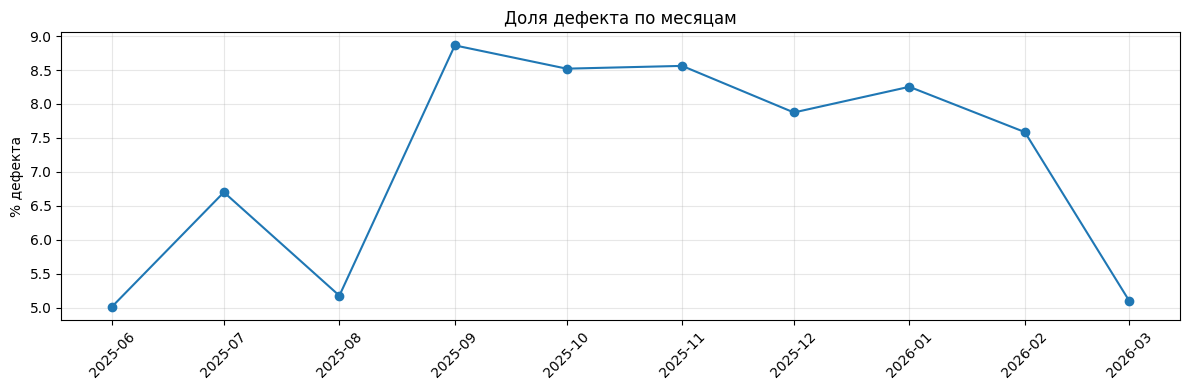

Вывод: задача несбалансированная, поэтому Accuracy не используем как основную метрику.


In [6]:
print_title("5. Временное разделение и короткий EDA")

order = df_feat.sort_values(TIME_COL, kind="mergesort").index


# Применяем один и тот же порядок одновременно к признакам и таргету,
# чтобы соответствие X и y не нарушилось.
df_feat = df_feat.loc[order].reset_index(drop=True)
y_all = y_all.loc[order].reset_index(drop=True)


# Все строки до HOLDOUT_START относятся к рабочей части данных.
# Всё, что позже этой даты, оставляем только для финальной проверки.
dev_mask = df_feat[TIME_COL] <= HOLDOUT_START

n_dev = int(dev_mask.sum())  # Количество строк до начала HOLDOUT
n_all = len(df_feat)         # Общее количество строк после сортировки


# Внутри рабочей части данных делаем последовательное временное разделение:
# 75% — TRAIN, следующие 15% — VALIDATION, последние 10% — PRETEST.
i1 = int(n_dev * 0.75)
i2 = int(n_dev * 0.90)


# Сохраняем индексы всех временных частей в одном словаре.
# Разбиение идёт без перемешивания, поэтому будущие данные не попадают в обучение.
IDX = {
    "TRAIN": np.arange(0, i1),
    "VAL": np.arange(i1, i2),
    "PRETEST": np.arange(i2, n_dev),
    "HOLDOUT": np.arange(n_dev, n_all),
}


# Формируем одну строку сводной таблицы для выбранного split:
# размер, число дефектов, доля дефекта и временные границы.
def split_row(name, idx):
    y = y_all.iloc[idx]                  # Таргет выбранной части
    t = df_feat[TIME_COL].iloc[idx]      # Даты выбранной части

    return {
        "split": name,
        "n": len(idx),                   # Количество строк
        "positive": int(y.sum()),        # Количество объектов класса 1
        "positive_rate": float(y.mean()),# Доля дефектов
        "time_min": t.min(),             # Начало временного диапазона
        "time_max": t.max(),             # Конец временного диапазона
    }


# Собираем общую таблицу по всем временным частям
split_info = pd.DataFrame([
    split_row(k, v)
    for k, v in IDX.items()
])

display(split_info)

eda = pd.DataFrame({
    "time": df_feat[TIME_COL],
    "y": y_all,
})

# Округляем дату до начала месяца, чтобы агрегировать статистику помесячно
eda["month"] = (
    eda["time"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Для каждого месяца считаем:
# количество объектов, количество дефектов и долю дефектов
monthly = (
    eda.groupby("month", as_index=False)
    .agg(
        n=("y", "size"),
        defect_cnt=("y", "sum"),
        defect_rate=("y", "mean"),
    )
)

display(monthly.tail(12))


# Строим график изменения доли дефекта по месяцам
plt.figure(figsize=(12, 4))

plt.plot(
    monthly["month"],
    monthly["defect_rate"] * 100,  # Переводим долю в проценты
    marker="o",
)

plt.title("Доля дефекта по месяцам")
plt.ylabel("% дефекта")

plt.grid(alpha=0.3)  # Добавляем лёгкую сетку для удобства чтения
plt.xticks(rotation=45)

plt.tight_layout()   # Автоматически выравниваем подписи и границы графика
plt.show()


# Из-за низкой доли положительного класса Accuracy может быть высокой
# даже у модели, которая почти всегда предсказывает отсутствие дефекта.
print("Вывод: задача несбалансированная, поэтому Accuracy не используем как основную метрику.")

In [7]:
print_title("6. Подготовка X: очистка признаков")


# Формирую общую матрицу признаков:
# удаляю дату и таргет, потому что они не должны напрямую участвовать в обучении модели.
X_all = df_feat.drop(
    columns=[TIME_COL, TARGET_COL],
    errors="ignore",
).copy()


# Заменяю бесконечные значения на пропуски.
X_all = X_all.replace([np.inf, -np.inf], np.nan)


# Нахожу оставшиеся datetime-колонки.
# Здесь даты не преобразую в числовые признаки, поэтому исключаю их из X.
dt_cols = list(
    X_all.select_dtypes(
        include=["datetime64[ns]", "datetimetz"]
    ).columns
)

X_all = X_all.drop(
    columns=dt_cols,
    errors="ignore",
)


# Разделяю общую матрицу признаков по заранее подготовленным временным индексам.
# Перемешивание не использую, чтобы сохранить временную последовательность.
X_train = X_all.iloc[IDX["TRAIN"]].copy()
X_val = X_all.iloc[IDX["VAL"]].copy()
X_pretest = X_all.iloc[IDX["PRETEST"]].copy()
X_holdout = X_all.iloc[IDX["HOLDOUT"]].copy()


# Аналогично разделяю таргет.
# Индексы полностью совпадают с соответствующими частями X.
y_train = y_all.iloc[IDX["TRAIN"]].copy()
y_val = y_all.iloc[IDX["VAL"]].copy()
y_pretest = y_all.iloc[IDX["PRETEST"]].copy()
y_holdout = y_all.iloc[IDX["HOLDOUT"]].copy()


# Задаю список строковых обозначений пропусков,
# которые могут встречаться в object-колонках вместо настоящего np.nan.
MISS_TOKENS = {
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a",
    "__na__",
    "нет данных",
    "None",
    "NA",
}


# Ищу object-колонки, которые на самом деле содержат числовые значения.
# Решение о преобразовании принимаю только по TRAIN,
# чтобы не использовать статистику VALIDATION, PRETEST и HOLDOUT.
def fit_object_to_num_cols(
    df_train,
    min_parse_rate=0.90,
    min_nunique=20,
):
    cols = []

    # Проверяю только колонки строкового типа
    for c in df_train.select_dtypes(include=["object"]).columns:
        raw = (
            df_train[c]
            .astype(str)
            .str.strip()
        )  # Убираю лишние пробелы перед преобразованием

        raw2 = raw.str.replace(
            ",",
            ".",
            regex=False,
        )  # Привожу десятичный разделитель к точке

        raw2 = raw2.where(
            ~raw2.str.lower().isin(MISS_TOKENS),
            np.nan,
        )  # Текстовые обозначения пропусков заменяю на np.nan

        parsed = pd.to_numeric(
            raw2,
            errors="coerce",
        )  # Всё, что не получилось преобразовать, становится NaN

        denom = raw2.notna().sum()  # Считаю число непустых исходных значений

        parse_rate = (
            parsed.notna().sum() / denom
            if denom > 0
            else 0
        )  # Считаю долю успешно распознанных чисел

        # Преобразую колонку только если:
        # не менее 90% непустых значений читаются как числа
        # и в колонке достаточно уникальных значений.
        if (
            parse_rate >= min_parse_rate
            and raw.nunique(dropna=True) >= min_nunique
        ):
            cols.append(c)

    return cols


# Применяю найденное преобразование к каждой части данных.
# Список колонок уже определён только на TRAIN.
def apply_object_to_num(df_part, cols):
    df_part = df_part.copy()

    for c in cols:
        raw = (
            df_part[c]
            .astype(str)
            .str.strip()
        )

        # Отдельно запоминаю, где в исходной колонке были пропуски
        miss = (
            raw.str.lower().isin(MISS_TOKENS)
            | df_part[c].isna()
        )

        # Превращаю строковую колонку в числовую
        df_part[c] = pd.to_numeric(
            raw.str.replace(",", ".", regex=False),
            errors="coerce",
        )

        # Добавляю бинарный признак пропуска:
        # 1 — значение отсутствовало, 0 — значение было заполнено.
        df_part[c + "__miss"] = miss.astype("int8")

    return df_part


# Определяю псевдочисловые object-колонки только на TRAIN
cast_cols = fit_object_to_num_cols(X_train)


# Одинаково преобразую все временные части
X_train = apply_object_to_num(X_train, cast_cols)
X_val = apply_object_to_num(X_val, cast_cols)
X_pretest = apply_object_to_num(X_pretest, cast_cols)
X_holdout = apply_object_to_num(X_holdout, cast_cols)


# На TRAIN нахожу признаки, где более 90% значений отсутствуют.
# Такие колонки почти не несут устойчивой информации.
drop_missing = (
    X_train.columns[
        X_train.isna().mean() > 0.90
    ]
    .tolist()
)


# На TRAIN нахожу константные признаки.
# Если у колонки только одно уникальное значение, модель не сможет использовать её для разделения.
drop_const = (
    X_train.columns[
        X_train.nunique(dropna=False) <= 1
    ]
    .tolist()
)


# Объединяю оба списка и удаляю возможные дубли
drop_cols = sorted(
    set(drop_missing + drop_const)
)


# Удаляю один и тот же набор колонок из всех частей данных
for part_name in [
    "X_train",
    "X_val",
    "X_pretest",
    "X_holdout",
]:
    globals()[part_name] = globals()[part_name].drop(
        columns=drop_cols,
        errors="ignore",
    )


# Получаю промежуточный список категориальных признаков после преобразований
cat_cols_tmp = list(
    X_train.select_dtypes(
        include=["object", "category"]
    ).columns
)


# Удаляю категориальные признаки с очень высокой кардинальностью.
# Более 300 уникальных значений могут привести к запоминанию объектов
# и заметно увеличить сложность кодирования.
high_card_cols = [
    c for c in cat_cols_tmp
    if X_train[c].nunique(dropna=True) > 300
    and not str(c).startswith(("f_pm", "f_ulo"))
    and "__unified" not in str(c)
]


# Созданные family-признаки и унифицированные категории сохраняю,
# даже если у них относительно много уникальных значений.
for part_name in [
    "X_train",
    "X_val",
    "X_pretest",
    "X_holdout",
]:
    globals()[part_name] = globals()[part_name].drop(
        columns=high_card_cols,
        errors="ignore",
    )


# После окончательного удаления колонок заново определяю типы признаков
cat_cols = list(
    X_train.select_dtypes(
        include=["object", "category"]
    ).columns
)

num_cols = [
    c for c in X_train.columns
    if c not in cat_cols
]


# CatBoost и последующий препроцессинг ожидают,
# что категориальные значения будут строками без np.nan.
for c in cat_cols:
    for part_name in [
        "X_train",
        "X_val",
        "X_pretest",
        "X_holdout",
    ]:
        part = globals()[part_name]

        part[c] = (
            part[c]
            .astype("object")
            .where(part[c].notna(), NA_TOKEN)
            .astype(str)
        )  # Все пропуски заменяю единым категориальным токеном


# Выполняю финальную проверку:
# набор и порядок колонок должны полностью совпадать во всех частях данных.
assert (
    list(X_train.columns)
    == list(X_val.columns)
    == list(X_pretest.columns)
    == list(X_holdout.columns)
)


# Вывожу основные результаты очистки
print("Object -> numeric:", len(cast_cols))
print("Удалено почти пустых / константных:", len(drop_cols))
print("Удалено high-card категорий:", len(high_card_cols))

# Проверяю размеры всех временных частей
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_pretest:", X_pretest.shape)
print("X_holdout:", X_holdout.shape)

# Контролирую итоговое количество числовых и категориальных признаков
print("num_cols:", len(num_cols))
print("cat_cols:", len(cat_cols))


6. Подготовка X: очистка признаков
Object -> numeric: 0
Удалено почти пустых / константных: 106
Удалено high-card категорий: 1
X_train: (15942, 102)
X_val: (3188, 102)
X_pretest: (2126, 102)
X_holdout: (3068, 102)
num_cols: 87
cat_cols: 15


In [8]:
print_title("7. Метрики")


# В этой задаче основное внимание уделяю PR-AUC, потому что классы сильно несбалансированы.
# Эта метрика оценивает качество ранжирования положительного класса через Precision и Recall.
def safe_pr_auc(y, p):
    # Если в выборке остался только один класс, корректно посчитать PR-AUC невозможно.
    # В таком случае возвращаю NaN, чтобы дальнейший код продолжил работать.
    return (
        np.nan
        if len(np.unique(y)) < 2
        else float(average_precision_score(y, p))
    )


# Дополнительно безопасно рассчитываю ROC-AUC.
# По этой метрике смотрю, насколько хорошо модель ставит положительные объекты выше отрицательных.
def safe_roc_auc(y, p):
    # Если в y присутствует только один класс, ROC-AUC также не имеет корректного значения.
    return (
        np.nan
        if len(np.unique(y)) < 2
        else float(roc_auc_score(y, p))
    )


# Отдельно оцениваю качество модели в верхней доле объектов с максимальным риском.
# При top_k_share=0.10 рассматриваю верхние 10% строк по вероятности дефекта.
# Так я имитирую ситуацию, когда производство может проверить только ограниченную часть рулонов.
def topk_metrics(y, p, top_k_share=0.10):
    # Сначала привожу входные данные к обычным numpy-массивам нужного типа
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    n = len(y)  # Считаю общее количество объектов в выборке

    # Определяю количество объектов, которые попадут в верхнюю группу риска.
    # Через max(1, ...) гарантирую выбор хотя бы одного объекта даже на маленькой выборке.
    k = max(1, int(n * top_k_share))

    total_pos = int(y.sum())       # Считаю общее количество реальных дефектов
    base_rate = float(y.mean())    # Считаю среднюю долю дефекта во всей выборке

    # Отдельно учитываю ситуацию, когда модель выдала одинаковый score всем объектам.
    # В этом случае ранжирования нет, поэтому честно выбрать лучшие верхние k строк невозможно.
    if len(np.unique(np.round(p, 12))) <= 1:
        return {
            # При одинаковых score ожидаемую Precision в Top-K приравниваю к общей доле дефекта
            f"precision_top_{int(top_k_share * 100)}": base_rate,

            # При отсутствии ранжирования ожидаемо нахожу примерно долю k / n
            # от общего количества положительных объектов
            f"recall_top_{int(top_k_share * 100)}": (
                min(1.0, k / n)
                if total_pos > 0
                else 0.0
            ),

            # Оцениваю ожидаемое число дефектов внутри выбранной группы
            f"tp_top_{int(top_k_share * 100)}": k * base_rate,

            # Сохраняю размер выбранной верхней группы
            f"n_top_{int(top_k_share * 100)}": k,

            # Отмечаю, что score оказался константным и реального ранжирования не было
            "topk_mode": "constant_score",
        }

    # Сортирую вероятности по убыванию и беру индексы верхних k объектов
    top_idx = np.argsort(-p)[:k]

    # Считаю, сколько реальных дефектов модель собрала внутри Top-K
    tp_top = int(y[top_idx].sum())

    return {
        # Precision@Top-K показывает,
        # какая доля самых рискованных объектов действительно оказалась дефектной
        f"precision_top_{int(top_k_share * 100)}": tp_top / k,

        # Recall@Top-K показывает,
        # какую долю всех реальных дефектов я нашёл в верхней группе риска
        f"recall_top_{int(top_k_share * 100)}": (
            tp_top / total_pos
            if total_pos > 0
            else 0.0
        ),

        # Сохраняю абсолютное количество найденных дефектов в Top-K
        f"tp_top_{int(top_k_share * 100)}": tp_top,

        # Сохраняю размер верхней группы риска
        f"n_top_{int(top_k_share * 100)}": k,

        # Отмечаю, что здесь использовалось полноценное ранжирование по score
        "topk_mode": "ranked",
    }


# Для общего сравнения моделей использую собственную итоговую метрику.
# В ней объединяю классические метрики и качество верхней очереди риска.
# Весами задаю относительную важность каждого компонента.
def row_quality_score(m):
    # Формирую названия Top-K метрик из глобального значения TOP_K_SHARE
    top_p = f"precision_top_{int(TOP_K_SHARE * 100)}"
    top_r = f"recall_top_{int(TOP_K_SHARE * 100)}"

    # Если PR-AUC посчитать не удалось, подставляю 0,
    # чтобы итоговый score в любом случае оставался числом.
    pr_auc = 0.0 if pd.isna(m["pr_auc"]) else m["pr_auc"]

    return float(
        0.20 * m["precision"]  # Учитываю чистоту очереди объектов, помеченных как дефект
        + 0.20 * m["recall"]   # Учитываю долю найденных реальных дефектов
        + 0.15 * m["f1"]       # Учитываю баланс между Precision и Recall
        + 0.15 * m[top_p]      # Учитываю качество верхних 10% объектов по риску
        + 0.15 * m[top_r]      # Учитываю долю дефектов, найденных в верхних 10%
        + 0.15 * pr_auc        # Учитываю общее качество ранжирования положительного класса
    )


# Для выбранного порога рассчитываю полный набор метрик.
# Сам порог переводит вероятности модели в бинарное решение: 0 или 1.
def evaluate_threshold(y, p, thr):
    # Привожу входные данные к numpy-массивам
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    # Считаю объект дефектным, если его вероятность не меньше выбранного порога
    pred = (p >= thr).astype(int)

    # Получаю элементы confusion matrix в фиксированном порядке:
    # TN — хорошие объекты определены правильно
    # FP — модель дала ложную тревогу
    # FN — модель пропустила дефект
    # TP — модель правильно нашла дефект
    tn, fp, fn, tp = confusion_matrix(
        y,
        pred,
        labels=[0, 1],
    ).ravel()

    # Собираю все рассчитанные метрики в один словарь
    m = {
        "thr": float(thr),

        # Смотрю, какая доля отмеченных моделью объектов действительно является дефектной
        "precision": float(
            precision_score(
                y,
                pred,
                zero_division=0,
            )
        ),

        # Смотрю, какую долю всех реальных дефектов модель смогла найти
        "recall": float(
            recall_score(
                y,
                pred,
                zero_division=0,
            )
        ),

        # Рассчитываю гармоническое среднее Precision и Recall
        "f1": float(
            f1_score(
                y,
                pred,
                zero_division=0,
            )
        ),

        # Дополнительно считаю метрики вероятностного ранжирования
        "pr_auc": safe_pr_auc(y, p),
        "roc_auc": safe_roc_auc(y, p),

        # Считаю долю всех строк, которые модель отправила в класс дефекта
        "flagged_share": float(pred.mean()),

        # Сохраняю абсолютные значения confusion matrix
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),

        # Добавляю Precision@Top-K, Recall@Top-K и связанные с ними показатели
        **topk_metrics(y, p, TOP_K_SHARE),
    }

    # В конце рассчитываю единую итоговую метрику для сравнения моделей
    m["row_quality_score"] = row_quality_score(m)

    return m


# Далее строю таблицу метрик для большого набора возможных порогов.
# Это позволяет выбирать порог по заданному правилу, а не вручную.
def threshold_table(y, p):
    p = np.asarray(p).astype(float)

    # Формирую комбинированную сетку порогов:
    # добавляю низкие значения, квантили прогнозов, равномерную сетку и крайние точки.
    grid = np.unique(
        np.concatenate([
            # Низкие пороги отдельно проверяю из-за редкого положительного класса
            np.array([0.0, 0.001, 0.005, 0.01]),

            # Через квантили получаю пороги, адаптированные к реальному распределению score
            np.quantile(
                p,
                np.linspace(0, 1, 101),
            ),

            # Дополнительно проверяю равномерную сетку от 0.05 до 0.95
            np.linspace(0.05, 0.95, 19),

            # Порогом 0.99 проверяю почти максимальное значение,
            # а 1.01 создаёт режим, где ни один объект не будет отмечен как дефект
            np.array([0.99, 1.01]),
        ])
    )

    rows = []

    # Для каждого порога рассчитываю полный набор метрик
    for thr in grid:
        m = evaluate_threshold(y, p, thr)

        # Если модель помечает более 35% объектов,
        # добавляю штраф за слишком широкую очередь риска.
        penalty = max(
            0.0,
            m["flagged_share"] - 0.35,
        )

        # Для выбора порога рассчитываю отдельный итоговый score:
        # основной вес отдаю F1, затем Precision и Recall.
        # Также учитываю качество верхней группы риска.
        m["threshold_score"] = (
            0.35 * m["f1"]
            + 0.30 * m["precision"]
            + 0.25 * m["recall"]
            + 0.10 * m[
                f"precision_top_{int(TOP_K_SHARE * 100)}"
            ]
            - 0.10 * penalty
        )

        rows.append(m)

    # Возвращаю таблицу, где каждая строка соответствует одному проверенному порогу
    return pd.DataFrame(rows)


# Лучший порог выбираю только по VALIDATION.
# PRETEST и HOLDOUT в подборе порога не использую.
def pick_threshold(y_val, p_val):
    # Сначала строю таблицу для всех проверенных порогов
    tbl = threshold_table(y_val, p_val)

    # В первую очередь выбираю максимальный threshold_score.
    # Если значения совпадают, последовательно отдаю приоритет:
    # 1. большей Precision;
    # 2. большему Recall;
    # 3. меньшей доле помеченных объектов.
    best = (
        tbl.sort_values(
            [
                "threshold_score",
                "precision",
                "recall",
                "flagged_share",
            ],
            ascending=[
                False,
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    # Возвращаю лучший порог и полную таблицу для дальнейшего анализа
    return float(best["thr"]), tbl


print("Метрики готовы.")


7. Метрики
Метрики готовы.


In [9]:
print_title("8. Baseline и простые модели")


# В этом словаре сохраняю прогнозы всех baseline и моделей
# в едином формате, чтобы затем корректно сравнить их между собой.
predictions = {}


# Считаю среднюю долю дефекта в TRAIN.
# Использую её как простейший константный вероятностный baseline.
train_rate = float(y_train.mean())


# Создаю отдельный генератор случайных чисел с фиксированным seed.
# Это нужно, чтобы случайный baseline каждый раз давал одинаковый результат.
rng = np.random.RandomState(RANDOM_STATE)


# Baseline 1: всегда предсказываю отсутствие дефекта.
# Вероятности везде равны 0, а порог 1.1 гарантирует,
# что ни одна строка не попадёт в положительный класс.
predictions["baseline_all_negative"] = {
    "type": "baseline",
    "fixed_thr": 1.1,
    "p_val": np.zeros(len(y_val)),
    "p_pretest": np.zeros(len(y_pretest)),
    "p_holdout": np.zeros(len(y_holdout)),
}


# Baseline 2: каждому объекту присваиваю вероятность,
# равную средней доле дефекта в TRAIN.
# Такой baseline не ранжирует объекты,
# но показывает качество простого прогноза общего уровня дефектности.
predictions["baseline_train_rate"] = {
    "type": "baseline",
    "fixed_thr": 0.5,
    "p_val": np.full(len(y_val), train_rate),
    "p_pretest": np.full(len(y_pretest), train_rate),
    "p_holdout": np.full(len(y_holdout), train_rate),
}


# Baseline 3: генерирую случайные вероятности от 0 до 1.
# Так проверяю, что реальные модели действительно
# ранжируют объекты лучше случайного порядка.
predictions["baseline_random"] = {
    "type": "baseline",
    "fixed_thr": None,
    "p_val": rng.random(len(y_val)),
    "p_pretest": rng.random(len(y_pretest)),
    "p_holdout": rng.random(len(y_holdout)),
}


# Создаю One-Hot Encoder для категориальных признаков.
# handle_unknown="ignore" позволяет обрабатывать новые категории,
# которые появились в VAL / PRETEST / HOLDOUT, но отсутствовали в TRAIN.
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
    )
except TypeError:
    # Для старых версий sklearn использую прежнее название параметра sparse.
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True,
    )


# Все признаки, ранее определённые как числовые,
# привожу к настоящему числовому типу во всех временных частях.
for X_part in [X_train, X_val, X_pretest, X_holdout]:
    for col in num_cols:
        X_part[col] = pd.to_numeric(
            X_part[col],
            errors="coerce",
        )  # Все нераспознаваемые значения перевожу в NaN


# Категориальные признаки привожу к строковому типу.
# Пропуски заменяю единым служебным токеном.
for X_part in [X_train, X_val, X_pretest, X_holdout]:
    for col in cat_cols:
        X_part[col] = (
            X_part[col]
            .where(X_part[col].notna(), NA_TOKEN)
            .astype(str)
        )


print_title("Проверка num_cols на строковые значения")


# В этот список сохраняю колонки, которые считались числовыми,
# но внутри TRAIN содержат настоящие строковые значения.
bad_num_cols = []


# Дополнительно проверяю каждую числовую колонку только на TRAIN.
# Так защищаюсь от смешанных типов вроде чисел и кодов формата O000000589.
for col in num_cols:
    s = X_train[col]

    # Ещё раз пробую преобразовать колонку в числовой тип
    s_num = pd.to_numeric(
        s,
        errors="coerce",
    )

    # Плохими считаю заполненные значения,
    # которые после преобразования превратились в NaN.
    bad_mask = (
        s.notna()
        & s_num.isna()
    )

    # Если такие значения присутствуют, колонку нельзя считать полностью числовой.
    if bad_mask.any():
        bad_num_cols.append(col)

        print("\nBAD NUM COL:", col)

        # Показываю несколько примеров, чтобы вручную проверить содержимое
        print(
            "examples:",
            s[bad_mask]
            .astype(str)
            .head(10)
            .tolist(),
        )


# Проверяю количество ошибочно определённых числовых колонок
print("\nПлохих num_cols:", len(bad_num_cols))


# Колонки со смешанным содержимым переношу из numeric в categorical.
# Например, код O000000589 нельзя корректно интерпретировать как число.
num_cols = [
    c for c in num_cols
    if c not in bad_num_cols
]


# Добавляю найденные смешанные колонки к категориальным.
# Через dict.fromkeys сохраняю порядок и одновременно удаляю дубли.
cat_cols = list(
    dict.fromkeys(
        list(cat_cols) + bad_num_cols
    )
)


# Проверяю итоговое количество признаков каждого типа
print("Итог num_cols:", len(num_cols))
print("Итог cat_cols:", len(cat_cols))


# Создаю общий препроцессор для простых sklearn-моделей.
# Числовые и категориальные признаки обрабатываю отдельно.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_cols,
        ),
        # Для числовых признаков заменяю пропуски медианой,
        # рассчитанной только на TRAIN во время fit пайплайна.

        (
            "cat",
            Pipeline([
                (
                    "imp",
                    SimpleImputer(
                        strategy="constant",
                        fill_value=NA_TOKEN,
                    ),
                ),
                # Для категориальных признаков заменяю пропуски отдельным значением

                (
                    "ohe",
                    ohe,
                ),
                # После заполнения кодирую категории через One-Hot Encoding
            ]),
            cat_cols,
        ),
    ],

    # Все колонки, которые не указаны в transformers, в модель не передаю
    remainder="drop",
)


# Формирую набор простых моделей для baseline-сравнения.
# Использую их не как финальное решение, а как понятную точку отсчёта.
models_simple = {
    # Логистическую регрессию использую как линейный baseline
    "model_logreg": LogisticRegression(
        max_iter=1000,              # Увеличиваю лимит итераций, чтобы модель успела сойтись
        class_weight="balanced",    # Компенсирую сильный дисбаланс классов
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # Неглубокое дерево решений использую как простой нелинейный baseline
    "model_tree": DecisionTreeClassifier(
        max_depth=6,                # Ограничиваю глубину, чтобы снизить переобучение
        min_samples_leaf=50,        # Требую минимум 50 объектов в каждом листе
        class_weight="balanced",    # Учитываю редкость положительного класса
        random_state=RANDOM_STATE,
    ),
}


# Последовательно обучаю каждую простую модель
for name, model in models_simple.items():
    # Объединяю подготовку признаков и модель в один Pipeline.
    # Так imputer и OHE обучаются только на TRAIN.
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model),
    ])

    # Обучаю весь пайплайн только на TRAIN
    pipe.fit(X_train, y_train)

    # Сохраняю вероятности положительного класса
    # для всех внешних временных частей.
    predictions[name] = {
        "type": "simple_model",
        "fixed_thr": None,

        # [:, 1] — вероятность класса 1, то есть дефекта
        "p_val": pipe.predict_proba(X_val)[:, 1],
        "p_pretest": pipe.predict_proba(X_pretest)[:, 1],
        "p_holdout": pipe.predict_proba(X_holdout)[:, 1],
    }

    print(name, "обучена")


# В конце вывожу базовую долю дефекта в TRAIN
print("TRAIN defect rate:", round(train_rate, 5))


8. Baseline и простые модели

Проверка num_cols на строковые значения

Плохих num_cols: 0
Итог num_cols: 87
Итог cat_cols: 15
model_logreg обучена
model_tree обучена
TRAIN defect rate: 0.07339


In [10]:
print_title("9. Улучшенный CatBoost: подбор параметров + train-only feature selection")


# Сначала определяю категориальные признаки в формате, который ожидает CatBoost.
# Возвращаю одновременно названия колонок и их числовые позиции.
def cat_features_idx(X):
    cat_cols_local = [
        c for c in X.columns
        if str(X[c].dtype) in ("object", "category")
    ]

    # CatBoost принимает индексы категориальных колонок относительно текущего X
    return cat_cols_local, [
        X.columns.get_loc(c)
        for c in cat_cols_local
    ]


# CatBoost обучаю с внутренним временным holdout только внутри TRAIN.
# Внешние VAL / PRETEST / HOLDOUT в подборе параметров не использую.
def train_catboost_inner(
    name,
    X_tr,
    y_tr,
    X_va,
    X_pr,
    X_ho,
    grid,
    model_type,
):
    # Последние 15% TRAIN оставляю как внутреннюю validation-часть
    split_i = int(len(X_tr) * 0.85)

    # Первые 85% TRAIN использую для обучения каждой конфигурации
    X_fit = X_tr.iloc[:split_i].copy()
    y_fit = y_tr.iloc[:split_i].copy()

    # Последние 15% TRAIN использую для early stopping
    # и выбора лучшего набора гиперпараметров
    X_es = X_tr.iloc[split_i:].copy()
    y_es = y_tr.iloc[split_i:].copy()

    # Нахожу категориальные признаки именно в текущем наборе X_tr
    cat_cols_local, cat_idx_local = cat_features_idx(X_tr)

    # Здесь сохраняю лучшую конфигурацию по внутреннему PR-AUC
    best = None

    # Вручную перебираю все варианты параметров из заданной сетки
    for params in grid:
        model = CatBoostClassifier(
            # Использую логистическую функцию потерь для бинарной классификации
            loss_function="Logloss",

            # Для early stopping CatBoost отслеживает AUC
            eval_metric="AUC",

            # Если параметр отсутствует в grid, использую значение по умолчанию
            iterations=params.get("iterations", 900),
            learning_rate=params.get("learning_rate", 0.03),
            depth=params.get("depth", 6),
            l2_leaf_reg=params.get("l2_leaf_reg", 10),

            # Фиксирую генератор случайности для воспроизводимости
            random_seed=RANDOM_STATE,

            # Отключаю подробный вывод каждой итерации
            verbose=False,

            # Останавливаю обучение, если метрика долго не улучшается
            od_type="Iter",
            od_wait=100,

            # CatBoost автоматически повышает вес редкого положительного класса
            auto_class_weights="Balanced",
        )

        # Обучаю модель только на первой части TRAIN
        model.fit(
            X_fit,
            y_fit,
            # Передаю позиции категориальных признаков
            cat_features=cat_idx_local,
            # Внутреннюю validation-часть беру только из TRAIN
            eval_set=(X_es, y_es),
            # После early stopping оставляю лучшую итерацию
            use_best_model=True,
        )

        # Получаю вероятности дефекта на внутренней validation-части TRAIN
        p_es = model.predict_proba(X_es)[:, 1]

        # Для выбора конфигурации использую PR-AUC,
        # так как положительный класс редкий
        score = safe_pr_auc(y_es, p_es)

        # Сохраняю всю информацию о текущем эксперименте
        row = {
            "model": model,
            "params": params,
            "inner_pr_auc": score,
            "best_iteration": model.get_best_iteration(),
        }

        # Если текущая конфигурация лучше, обновляю лучший результат
        if best is None or score > best["inner_pr_auc"]:
            best = row

    # Беру модель с лучшим внутренним PR-AUC
    model = best["model"]

    # Сохраняю прогнозы лучшей конфигурации
    # на внешних временных частях для дальнейшей честной оценки
    predictions[name] = {
        "type": model_type,
        "fixed_thr": None,

        # VALIDATION дальше использую для выбора порога и финальной модели
        "p_val": model.predict_proba(X_va)[:, 1],

        # PRETEST использую для дополнительной проверки устойчивости
        "p_pretest": model.predict_proba(X_pr)[:, 1],

        # HOLDOUT оставляю только для финальной проверки на будущих данных
        "p_holdout": model.predict_proba(X_ho)[:, 1],
    }

    # Вывожу краткую информацию о лучшем внутреннем эксперименте
    print(name)
    print("best_params:", best["params"])
    print("inner PR-AUC:", round(float(best["inner_pr_auc"]), 5))
    print("best_iteration:", best["best_iteration"])

    # Возвращаю саму модель и информацию о лучшей конфигурации
    return model, best


# Задаю небольшую ручную сетку параметров CatBoost.
# Проверяю более простое дерево, базовый вариант
# и более медленную модель с усиленной регуляризацией.
CATBOOST_GRID = [
    {
        "depth": 4,
        "learning_rate": 0.04,
        "l2_leaf_reg": 10,
        "iterations": 900,
    },
    {
        "depth": 6,
        "learning_rate": 0.03,
        "l2_leaf_reg": 10,
        "iterations": 1000,
    },
    {
        "depth": 6,
        "learning_rate": 0.02,
        "l2_leaf_reg": 20,
        "iterations": 1200,
    },
]


# Сначала обучаю базовый CatBoost на полном наборе очищенных признаков
catboost_base_model, cb_base_info = train_catboost_inner(
    name="model_catboost_base",
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    X_pr=X_pretest,
    X_ho=X_holdout,
    grid=CATBOOST_GRID,
    model_type="complex_model",
)


# Получаю важности признаков из базовой модели.
# Feature selection строю только на модели, обученной внутри TRAIN.
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_base_model.get_feature_importance(),
}).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)


# Часть созданных вручную признаков сохраняю обязательно,
# даже если они не попали в обычный TOP по importance.
always_keep = [
    c for c in X_train.columns

    # Сохраняю семейства PM / ULO и индикаторы режима
    if str(c).startswith(("f_pm_", "f_ulo_", "ind_"))

    # Сохраняю лаговые признаки предыдущего дня
    or str(c).startswith("mean_yest_")

    # Сохраняю унифицированные признаки плоскостности
    or str(c).endswith(("__unified", "__mm_per_m"))
]


# Беру TOP_SELECTED_FEATURES наиболее важных признаков базового CatBoost
selected_features = (
    importance["feature"]
    .head(TOP_SELECTED_FEATURES)
    .tolist()
)


# Добавляю обязательные engineered-признаки.
# Через dict.fromkeys удаляю дубли и сохраняю порядок.
selected_features = list(
    dict.fromkeys(
        selected_features + always_keep
    )
)


# На всякий случай оставляю только реально существующие колонки
selected_features = [
    c for c in selected_features
    if c in X_train.columns
]


# Формирую новые матрицы только с выбранными признаками.
# Набор и порядок колонок сохраняю одинаковыми для всех временных частей.
X_train_fs = X_train[selected_features].copy()
X_val_fs = X_val[selected_features].copy()
X_pretest_fs = X_pretest[selected_features].copy()
X_holdout_fs = X_holdout[selected_features].copy()


# Показываю итоговое количество выбранных признаков
# относительно полного набора
print(
    "\nSelected features:",
    len(selected_features),
    "/",
    X_train.shape[1],
)


# Вывожу 30 самых важных признаков базовой модели
display(
    importance.head(30)
)


# Повторно обучаю CatBoost уже на сокращённом наборе признаков.
# Параметры снова подбираю только внутри TRAIN.
catboost_fs_model, cb_fs_info = train_catboost_inner(
    name="model_catboost_fe_fs",
    X_tr=X_train_fs,
    y_tr=y_train,
    X_va=X_val_fs,
    X_pr=X_pretest_fs,
    X_ho=X_holdout_fs,
    grid=CATBOOST_GRID,
    model_type="improved_complex_model",
)


9. Улучшенный CatBoost: подбор параметров + train-only feature selection
model_catboost_base
best_params: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 1000}
inner PR-AUC: 0.30494
best_iteration: 66

Selected features: 77 / 102


,feature,importance
0,Толщина (СЗ),37.083922
1,Заданный план охлаждения (PM),6.889874
2,Ширина (СЗ),6.524623
3,Агрегат_бригада_резки,5.005396
4,"Скорость смотки, макс",4.299343
5,"Скорость смотки, сред",3.919024
6,f_ulo_family_6,3.805062
7,Назначение многозначное (СЗ),2.467895
8,Покупатель (СЗ),2.131831
9,Плановая неделя отгрузки (СЗ),1.650846


model_catboost_fe_fs
best_params: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 1000}
inner PR-AUC: 0.31767
best_iteration: 67


In [11]:
print_title("9.1. Дополнительный эксперимент: Optuna CatBoost")

# Здесь отдельно проверяю автоматический подбор гиперпараметров.
# Optuna использует только внутреннее временное разделение TRAIN:
# - первые 85% TRAIN использую для обучения;
# - последние 15% TRAIN оставляю для inner validation.
# Внешние VALIDATION / PRETEST / HOLDOUT в подборе параметров не использую.


# Для эксперимента беру сокращённый набор признаков после train-only feature selection
X_opt_train = X_train_fs.copy()
X_opt_val = X_val_fs.copy()
X_opt_pretest = X_pretest_fs.copy()
X_opt_holdout = X_holdout_fs.copy()

y_opt_train = y_train.copy()


# Отделяю последние 15% TRAIN для внутренней проверки параметров
opt_i = int(len(X_opt_train) * 0.85)

X_opt_fit = X_opt_train.iloc[:opt_i].copy()
y_opt_fit = y_opt_train.iloc[:opt_i].copy()

X_opt_es = X_opt_train.iloc[opt_i:].copy()
y_opt_es = y_opt_train.iloc[opt_i:].copy()


# Получаю позиции категориальных признаков для CatBoost
cat_cols_opt, cat_idx_opt = cat_features_idx(X_opt_train)


# Определяю целевую функцию Optuna.
# Каждый вызов функции соответствует одному набору параметров CatBoost.
def objective(trial):
    # Optuna самостоятельно выбирает значения внутри заданных диапазонов
    params = {
        "depth": trial.suggest_int(
            "depth",
            4,
            7,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.015,
            0.06,
            log=True,
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            5,
            30,
            log=True,
        ),

        "iterations": trial.suggest_int(
            "iterations",
            700,
            1300,
            step=100,
        ),
    }

    # Создаю CatBoost с параметрами текущего trial
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",

        iterations=params["iterations"],
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],

        random_seed=RANDOM_STATE,
        verbose=False,

        # Останавливаю обучение, если метрика не улучшается 100 итераций
        od_type="Iter",
        od_wait=100,

        # Автоматически учитываю дисбаланс классов
        auto_class_weights="Balanced",
    )

    # Обучаю модель только на первых 85% TRAIN
    model.fit(
        X_opt_fit,
        y_opt_fit,
        cat_features=cat_idx_opt,
        eval_set=(X_opt_es, y_opt_es),
        use_best_model=True,
    )

    # Получаю прогноз на последних 15% TRAIN
    p_inner = model.predict_proba(X_opt_es)[:, 1]

    # В качестве главной метрики оптимизации использую PR-AUC
    inner_pr_auc = safe_pr_auc(y_opt_es, p_inner)

    # Сохраняю дополнительные значения текущего эксперимента
    trial.set_user_attr(
        "inner_roc_auc",
        safe_roc_auc(y_opt_es, p_inner),
    )

    trial.set_user_attr(
        "best_iteration",
        model.get_best_iteration(),
    )

    # Optuna будет максимизировать это значение
    return inner_pr_auc


# Фиксирую sampler, чтобы результаты поиска можно было воспроизвести
sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
)


# Создаю задачу на максимизацию PR-AUC
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="catboost_optuna",
)


# Запускаю простой поиск по 20 наборам параметров
study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True,
)


# Получаю лучший эксперимент
best_trial = study.best_trial
best_params = best_trial.params.copy()


# Вывожу результаты всех экспериментов
optuna_results = study.trials_dataframe(
    attrs=(
        "number",
        "value",
        "params",
        "user_attrs",
        "state",
    )
)

optuna_results = (
    optuna_results
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)

display(optuna_results)


# После выбора параметров повторно обучаю лучшую модель
# на том же внутреннем разделении TRAIN.
catboost_optuna_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",

    iterations=best_params["iterations"],
    learning_rate=best_params["learning_rate"],
    depth=best_params["depth"],
    l2_leaf_reg=best_params["l2_leaf_reg"],

    random_seed=RANDOM_STATE,
    verbose=False,

    od_type="Iter",
    od_wait=100,

    auto_class_weights="Balanced",
)


catboost_optuna_model.fit(
    X_opt_fit,
    y_opt_fit,
    cat_features=cat_idx_opt,
    eval_set=(X_opt_es, y_opt_es),
    use_best_model=True,
)


# Получаю прогнозы лучшей Optuna-модели на внешних временных частях
p_val_optuna = catboost_optuna_model.predict_proba(X_opt_val)[:, 1]
p_pretest_optuna = catboost_optuna_model.predict_proba(X_opt_pretest)[:, 1]
p_holdout_optuna = catboost_optuna_model.predict_proba(X_opt_holdout)[:, 1]


# Добавляю модель в общий словарь для дальнейшего сравнения
optuna_model_name = "model_catboost_optuna"

predictions[optuna_model_name] = {
    "type": "optuna_experiment",
    "fixed_thr": None,
    "p_val": p_val_optuna,
    "p_pretest": p_pretest_optuna,
    "p_holdout": p_holdout_optuna,
}


# Вывожу параметры и внутренние метрики лучшего trial
print("Лучшая Optuna-модель добавлена в predictions как:", optuna_model_name)

print("best_params:", best_params)

print(
    "inner PR-AUC:",
    round(float(best_trial.value), 5),
)

print(
    "inner ROC-AUC:",
    round(float(best_trial.user_attrs["inner_roc_auc"]), 5),
)

print(
    "best_iteration:",
    best_trial.user_attrs["best_iteration"],
)


# Внешнюю VALIDATION использую только после завершения Optuna
# для честной оценки уже выбранной конфигурации.
print("\nВнешняя VALIDATION только для честной оценки:")

print(
    "VAL PR-AUC:",
    round(safe_pr_auc(y_val, p_val_optuna), 5),
)

print(
    "VAL ROC-AUC:",
    round(safe_roc_auc(y_val, p_val_optuna), 5),
)

[I 2026-07-11 14:51:03,974] A new study created in memory with name: catboost_optuna



9.1. Дополнительный эксперимент: Optuna CatBoost


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-07-11 14:51:15,015] Trial 0 finished with value: 0.31899482549344993 and parameters: {'depth': 5, 'learning_rate': 0.056037442484973436, 'l2_leaf_reg': 18.55974501953827, 'iterations': 1100}. Best is trial 0 with value: 0.31899482549344993.
[I 2026-07-11 14:51:35,249] Trial 1 finished with value: 0.31555391045204584 and parameters: {'depth': 4, 'learning_rate': 0.018621270917228806, 'l2_leaf_reg': 5.54840098004973, 'iterations': 1300}. Best is trial 0 with value: 0.31899482549344993.
[I 2026-07-11 14:51:48,034] Trial 2 finished with value: 0.30846158243545385 and parameters: {'depth': 6, 'learning_rate': 0.04003072254642017, 'l2_leaf_reg': 5.187855301194419, 'iterations': 1300}. Best is trial 0 with value: 0.31899482549344993.
[I 2026-07-11 14:52:06,024] Trial 3 finished with value: 0.33286576701419124 and parameters: {'depth': 7, 'learning_rate': 0.020134096332832998, 'l2_leaf_reg': 6.9255988105288315, 'iterations': 800}. Best is trial 3 with value: 0.33286576701419124.
[I 202

,number,value,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,user_attrs_best_iteration,user_attrs_inner_roc_auc,state
0,11,0.336125,7,700,28.825994,0.024161,112,0.859582,COMPLETE
1,8,0.334468,4,1200,28.208356,0.055896,52,0.856702,COMPLETE
2,3,0.332866,7,800,6.925599,0.020134,85,0.859613,COMPLETE
3,19,0.325521,6,800,12.513438,0.034493,79,0.862213,COMPLETE
4,0,0.318995,5,1100,18.559745,0.056037,55,0.857228,COMPLETE
5,5,0.317079,6,900,8.439228,0.018200,141,0.855776,COMPLETE
6,12,0.316866,7,700,29.770636,0.025388,94,0.858887,COMPLETE
7,4,0.315584,5,900,10.841480,0.031047,104,0.856170,COMPLETE
8,1,0.315554,4,1300,5.548401,0.018621,224,0.855030,COMPLETE
9,13,0.314009,7,1100,23.122011,0.059334,40,0.857901,COMPLETE


Лучшая Optuna-модель добавлена в predictions как: model_catboost_optuna
best_params: {'depth': 7, 'learning_rate': 0.024161291758876477, 'l2_leaf_reg': 28.82599394762007, 'iterations': 700}
inner PR-AUC: 0.33612
inner ROC-AUC: 0.85958
best_iteration: 112

Внешняя VALIDATION только для честной оценки:
VAL PR-AUC: 0.37101
VAL ROC-AUC: 0.86836


**Попробовал несколько способов поиска параметров** 

Optuna лучше GridSearch тем, что не перебирает все комбинации подряд, а постепенно ищет более перспективные параметры. 

Поэтому обычно быстрее находит сильную модель при том же числе запусков.

Минус: результат менее прозрачен и зависит от числа trials и sampler.

Здесь попробовал Optuna как дополнительный эксперимент, чтобы проверить, сможет ли автоматический подбор параметров улучшить CatBoost относительно обычной фиксированной сетки.


In [12]:
print_title("10. Оценка моделей и выбор лучшей")


# Здесь собираю метрики всех моделей на всех временных выборках
eval_rows = []

# Для каждой модели отдельно сохраняю таблицу проверки порогов
threshold_tables = {}


# Последовательно оцениваю все baseline и обученные модели
for model_name, pack in predictions.items():

    # Для некоторых baseline использую заранее зафиксированный порог
    if pack.get("fixed_thr") is not None:
        thr = float(pack["fixed_thr"])
        threshold_tables[model_name] = None

    else:
        # Для остальных моделей подбираю порог только на VALIDATION
        thr, tbl = pick_threshold(
            y_val,
            pack["p_val"],
        )

        # Полную таблицу порогов сохраняю для дальнейшего анализа
        threshold_tables[model_name] = tbl

    # Сохраняю выбранный порог в общем словаре модели
    predictions[model_name]["best_thr"] = thr

    # Один и тот же порог, выбранный по VALIDATION,
    # применяю к VAL, PRETEST и HOLDOUT
    for split_name, y_true, p in [
        ("VAL", y_val, pack["p_val"]),
        ("PRETEST", y_pretest, pack["p_pretest"]),
        ("HOLDOUT", y_holdout, pack["p_holdout"]),
    ]:
        # Считаю полный набор метрик текущей модели
        m = evaluate_threshold(
            y_true,
            p,
            thr,
        )

        # Добавляю служебную информацию
        m["model_name"] = model_name
        m["model_type"] = pack["type"]
        m["split"] = split_name

        eval_rows.append(m)


# Собираю результаты всех моделей в одну таблицу
eval_results = pd.DataFrame(eval_rows)


# Формирую названия Top-K колонок из выбранного TOP_K_SHARE
top_p_col = f"precision_top_{int(TOP_K_SHARE * 100)}"
top_r_col = f"recall_top_{int(TOP_K_SHARE * 100)}"
tp_top_col = f"tp_top_{int(TOP_K_SHARE * 100)}"
n_top_col = f"n_top_{int(TOP_K_SHARE * 100)}"


# Определяю основные колонки для итоговой таблицы
main_cols = [
    "model_name",
    "model_type",
    "split",
    "thr",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc",
    "flagged_share",
    top_p_col,
    top_r_col,
    tp_top_col,
    n_top_col,
    "tp",
    "fp",
    "fn",
    "tn",
    "row_quality_score",
]


display(
    eval_results[main_cols]
    .sort_values(
        ["split", "row_quality_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


# Для выбора финальной модели использую только VALIDATION
# и исключаю простые baseline
val_models = eval_results[
    (eval_results["split"] == "VAL")
    & (~eval_results["model_type"].eq("baseline"))
].copy()


# Выбираю модель с максимальным row_quality_score на VALIDATION
best_row = (
    val_models
    .sort_values(
        "row_quality_score",
        ascending=False,
    )
    .iloc[0]
)


# Сохраняю название лучшей модели и выбранный для неё порог
final_model_name = best_row["model_name"]
best_thr = float(best_row["thr"])


# Получаю вероятности лучшей модели для следующих блоков ноутбука
p_val = predictions[final_model_name]["p_val"]
p_pretest = predictions[final_model_name]["p_pretest"]
p_holdout = predictions[final_model_name]["p_holdout"]

print("Финальная модель:", final_model_name)
print("Порог:", round(best_thr, 6))
print(
    "VAL row_quality_score:",
    round(float(best_row["row_quality_score"]), 5),
)


# Отдельно формирую компактную таблицу только для лучшей модели
# на всех трёх внешних временных выборках
best_model_metrics = (
    eval_results[
        eval_results["model_name"] == final_model_name
    ][main_cols]
    .sort_values(
        "split",
        key=lambda s: s.map({
            "VAL": 0,
            "PRETEST": 1,
            "HOLDOUT": 2,
        }),
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 120)
print("МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ НА ВСЕХ ВЫБОРКАХ")
print("=" * 120)


# Вывожу метрики каждой выборки отдельным понятным блоком,
# чтобы не искать значения в общей большой таблице
for _, row in best_model_metrics.iterrows():
    print(f"\n{row['split']}:")
    print(f"- threshold: {row['thr']:.6f}")
    print(f"- precision: {row['precision']:.4f}")
    print(f"- recall: {row['recall']:.4f}")
    print(f"- f1: {row['f1']:.4f}")
    print(f"- PR-AUC: {row['pr_auc']:.4f}")
    print(f"- ROC-AUC: {row['roc_auc']:.4f}")
    print(f"- flagged_share: {row['flagged_share']:.4f}")
    print(f"- Precision@Top-{int(TOP_K_SHARE * 100)}%: {row[top_p_col]:.4f}")
    print(f"- Recall@Top-{int(TOP_K_SHARE * 100)}%: {row[top_r_col]:.4f}")
    print(f"- TP / FP / FN / TN: {int(row['tp'])} / {int(row['fp'])} / {int(row['fn'])} / {int(row['tn'])}")
    print(f"- row_quality_score: {row['row_quality_score']:.4f}")


10. Оценка моделей и выбор лучшей


,model_name,model_type,split,thr,precision,recall,f1,pr_auc,roc_auc,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,tp,fp,fn,tn,row_quality_score
0,model_catboost_optuna,optuna_experiment,HOLDOUT,0.467362,0.127237,0.810127,0.219931,0.236465,0.828032,0.327901,0.189542,0.367089,58.000000,306,128,878,30,2032,0.339427
1,model_tree,simple_model,HOLDOUT,0.500000,0.128993,0.664557,0.216049,0.206863,0.829211,0.265319,0.202614,0.392405,62.000000,306,105,709,53,2201,0.311400
2,model_catboost_base,complex_model,HOLDOUT,0.550000,0.142450,0.632911,0.232558,0.242317,0.827776,0.228814,0.176471,0.341772,54.000000,306,100,602,58,2308,0.304040
3,model_catboost_fe_fs,improved_complex_model,HOLDOUT,0.543131,0.133697,0.620253,0.219978,0.236011,0.823472,0.238918,0.189542,0.367089,58.000000,306,98,635,60,2275,0.302683
4,baseline_random,baseline,HOLDOUT,0.001000,0.051583,1.000000,0.098106,0.056421,0.525338,0.998370,0.068627,0.132911,21.000000,306,158,2905,0,5,0.263727
5,model_logreg,simple_model,HOLDOUT,0.291869,0.049643,0.924051,0.094224,0.062182,0.456155,0.958605,0.062092,0.120253,19.000000,306,146,2795,12,115,0.245551
6,baseline_all_negative,baseline,HOLDOUT,1.100000,0.000000,0.000000,0.000000,0.051499,0.500000,0.000000,0.051499,0.099739,15.758801,306,0,0,158,2910,0.030411
7,baseline_train_rate,baseline,HOLDOUT,0.500000,0.000000,0.000000,0.000000,0.051499,0.500000,0.000000,0.051499,0.099739,15.758801,306,0,0,158,2910,0.030411
8,model_catboost_optuna,optuna_experiment,PRETEST,0.467362,0.189591,0.894737,0.312883,0.373843,0.870958,0.379586,0.382075,0.473684,81.000000,212,153,654,18,1301,0.448239
9,model_catboost_fe_fs,improved_complex_model,PRETEST,0.543131,0.210863,0.771930,0.331242,0.378597,0.865406,0.294450,0.419811,0.520468,89.000000,212,132,494,39,1461,0.444076


Финальная модель: model_catboost_optuna
Порог: 0.467362
VAL row_quality_score: 0.45326

МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ НА ВСЕХ ВЫБОРКАХ

VAL:
- threshold: 0.467362
- precision: 0.2120
- recall: 0.8884
- f1: 0.3423
- PR-AUC: 0.3710
- ROC-AUC: 0.8684
- flagged_share: 0.3300
- Precision@Top-10%: 0.3711
- Recall@Top-10%: 0.4701
- TP / FP / FN / TN: 223 / 829 / 28 / 2108
- row_quality_score: 0.4533

PRETEST:
- threshold: 0.467362
- precision: 0.1896
- recall: 0.8947
- f1: 0.3129
- PR-AUC: 0.3738
- ROC-AUC: 0.8710
- flagged_share: 0.3796
- Precision@Top-10%: 0.3821
- Recall@Top-10%: 0.4737
- TP / FP / FN / TN: 153 / 654 / 18 / 1301
- row_quality_score: 0.4482

HOLDOUT:
- threshold: 0.467362
- precision: 0.1272
- recall: 0.8101
- f1: 0.2199
- PR-AUC: 0.2365
- ROC-AUC: 0.8280
- flagged_share: 0.3279
- Precision@Top-10%: 0.1895
- Recall@Top-10%: 0.3671
- TP / FP / FN / TN: 128 / 878 / 30 / 2032
- row_quality_score: 0.3394


In [13]:
print_title("11. Пороги")


# Получаю таблицу всех порогов финальной модели,
# которую ранее рассчитал только на VALIDATION
tbl = threshold_tables.get(final_model_name)


if tbl is not None:
    policy_rows = []

    # Формирую три варианта применения одной и той же модели
    candidates = {
        # В первом варианте отдаю главный приоритет Precision,
        # но сохраняю Recall не ниже 0.30
        "precision_first": tbl[
            (tbl["recall"] >= 0.30)
            & (tbl["flagged_share"] <= 0.25)
        ],

        # Во втором варианте использую сбалансированный выбор по общей threshold_score
        "balanced": tbl,

        # В третьем варианте повышаю приоритет Recall
        "recall_first": tbl[
            (tbl["recall"] >= 0.50)
            & (tbl["flagged_share"] <= 0.50)
        ],
    }


    for name, d in candidates.items():
        if len(d) == 0:
            continue

        if name == "balanced":
            # Для balanced выбираю максимум общей комбинированной метрики
            r = (
                d.sort_values(
                    "threshold_score",
                    ascending=False,
                )
                .iloc[0]
            )

        else:
            # Для precision_first и recall_first сначала максимизирую Precision,
            # затем Recall и только после этого уменьшаю объём очереди
            r = (
                d.sort_values(
                    ["precision", "recall", "flagged_share"],
                    ascending=[False, False, True],
                )
                .iloc[0]
            )

        policy_rows.append({
            "policy": name,
            "thr": r["thr"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "flagged_share": r["flagged_share"],
            top_p_col: r[top_p_col],
            top_r_col: r[top_r_col],
        })


    # Собираю итоговую таблицу вариантов порога
    threshold_policy = pd.DataFrame(policy_rows)

    display(threshold_policy)


    # Для дальнейшей работы выбираю вариант с максимальной Precision
    precision_row = (
        threshold_policy[
            threshold_policy["policy"] == "precision_first"
        ]
        .iloc[0]
    )


    # Перезаписываю основной порог финальной модели
    best_thr = float(precision_row["thr"])

    # Сохраняю новый порог в общем словаре моделей
    predictions[final_model_name]["best_thr"] = best_thr


    print("\nДля дальнейших расчётов выбран порог PRECISION_FIRST")
    print("Модель:", final_model_name)
    print("Новый порог:", round(best_thr, 6))
    print("VALIDATION precision:", round(float(precision_row["precision"]), 4))
    print("VALIDATION recall:", round(float(precision_row["recall"]), 4))
    print("VALIDATION f1:", round(float(precision_row["f1"]), 4))
    print("VALIDATION flagged_share:", round(float(precision_row["flagged_share"]), 4))


    # Пересчитываю метрики финальной модели уже с новым порогом
    updated_rows = []

    for split_name, y_true, p in [
        ("VAL", y_val, p_val),
        ("PRETEST", y_pretest, p_pretest),
        ("HOLDOUT", y_holdout, p_holdout),
    ]:
        m = evaluate_threshold(
            y_true,
            p,
            best_thr,
        )

        m["model_name"] = final_model_name
        m["model_type"] = predictions[final_model_name]["type"]
        m["split"] = split_name

        updated_rows.append(m)


    # Удаляю старые строки финальной модели,
    # которые были рассчитаны со сбалансированным порогом
    eval_results = eval_results[
        eval_results["model_name"] != final_model_name
    ].copy()


    # Добавляю новые метрики с precision-first порогом
    eval_results = pd.concat(
        [
            eval_results,
            pd.DataFrame(updated_rows),
        ],
        ignore_index=True,
    )


    print("\nМетрики финальной модели с новым порогом:")

    display(
        eval_results[
            eval_results["model_name"] == final_model_name
        ][main_cols]
        .sort_values(
            "split",
            key=lambda s: s.map({
                "VAL": 0,
                "PRETEST": 1,
                "HOLDOUT": 2,
            }),
        )
        .reset_index(drop=True)
    )


print(
    "\nОсновной порог для дальнейших расчётов:",
    round(best_thr, 6),
)


11. Пороги


,policy,thr,precision,recall,f1,flagged_share,precision_top_10,recall_top_10
0,precision_first,0.774344,0.481250,0.306773,0.374696,0.050188,0.371069,0.47012
1,balanced,0.467362,0.211977,0.888446,0.342287,0.329987,0.371069,0.47012
2,recall_first,0.681856,0.345455,0.529880,0.418239,0.120765,0.371069,0.47012



Для дальнейших расчётов выбран порог PRECISION_FIRST
Модель: model_catboost_optuna
Новый порог: 0.774344
VALIDATION precision: 0.4813
VALIDATION recall: 0.3068
VALIDATION f1: 0.3747
VALIDATION flagged_share: 0.0502

Метрики финальной модели с новым порогом:


,model_name,model_type,split,thr,precision,recall,f1,pr_auc,roc_auc,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,tp,fp,fn,tn,row_quality_score
0,model_catboost_optuna,optuna_experiment,VAL,0.774344,0.481250,0.306773,0.374696,0.371008,0.868360,0.050188,0.371069,0.470120,118.0,318,77,83,174,2854,0.395638
1,model_catboost_optuna,optuna_experiment,PRETEST,0.774344,0.531646,0.245614,0.336000,0.373843,0.870958,0.037159,0.382075,0.473684,81.0,212,42,37,129,1918,0.390292
2,model_catboost_optuna,optuna_experiment,HOLDOUT,0.774344,0.373494,0.196203,0.257261,0.236465,0.828032,0.027053,0.189542,0.367089,58.0,306,31,52,127,2858,0.271493



Основной порог для дальнейших расчётов: 0.774344


ПРОГНОЗИРОВАНИЕ СУТОК

In [14]:
print_title("12. OOF-калибровка внутри TRAIN и прогноз процента дефекта")


from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit


# Количество последовательных временных фолдов внутри TRAIN.
# Каждый следующий фолд проверяется только на более поздних данных.
OOF_N_SPLITS = 5


# Для OOF-калибровки нужно использовать тот же набор признаков,
# на котором была построена выбранная финальная модель.
if final_model_name in [
    "model_catboost_fe_fs",
    "model_catboost_optuna",
]:
    X_oof_train = X_train_fs.copy()

elif final_model_name in [
    "model_catboost_base",
    "model_logreg",
    "model_tree",
]:
    X_oof_train = X_train.copy()

else:
    raise ValueError(
        f"Для модели {final_model_name} "
        "не задано построение OOF-прогнозов."
    )


y_oof_train = y_train.reset_index(drop=True).copy()
X_oof_train = X_oof_train.reset_index(drop=True).copy()

train_times = (
    df_feat[TIME_COL]
    .iloc[IDX["TRAIN"]]
    .reset_index(drop=True)
)


# Создаю новую модель для одного OOF-фолда.
# Гиперпараметры уже были выбраны ранее только внутри TRAIN.
def make_oof_model(model_name):

    if model_name == "model_logreg":
        return Pipeline([
            (
                "prep",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ])

    if model_name == "model_tree":
        return Pipeline([
            (
                "prep",
                clone(preprocessor),
            ),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=6,
                    min_samples_leaf=50,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    if model_name == "model_catboost_base":
        params = cb_base_info["params"].copy()
        best_iteration = int(
            cb_base_info.get(
                "best_iteration",
                params.get("iterations", 900) - 1,
            )
        )

    elif model_name == "model_catboost_fe_fs":
        params = cb_fs_info["params"].copy()
        best_iteration = int(
            cb_fs_info.get(
                "best_iteration",
                params.get("iterations", 900) - 1,
            )
        )

    elif model_name == "model_catboost_optuna":
        params = best_params.copy()
        best_iteration = int(
            best_trial.user_attrs.get(
                "best_iteration",
                params.get("iterations", 900) - 1,
            )
        )

    else:
        raise ValueError(
            f"Неизвестная модель для OOF: {model_name}"
        )

    # Если CatBoost завершил обучение на конкретной лучшей итерации,
    # использую это число как фиксированное количество деревьев.
    iterations = (
        best_iteration + 1
        if best_iteration >= 0
        else int(params.get("iterations", 900))
    )

    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",

        iterations=max(1, iterations),
        learning_rate=float(
            params.get("learning_rate", 0.03)
        ),
        depth=int(
            params.get("depth", 6)
        ),
        l2_leaf_reg=float(
            params.get("l2_leaf_reg", 10)
        ),

        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,

        verbose=False,
        allow_writing_files=False,
    )


# Создаю последовательные временные OOF-фолды.
# В каждом фолде модель обучается только на прошлом
# и прогнозирует следующий временной блок.
tscv = TimeSeriesSplit(
    n_splits=OOF_N_SPLITS,
)


# Здесь будут храниться OOF-прогнозы TRAIN.
# Первые строки TRAIN могут остаться без OOF-прогноза,
# потому что они используются как начальная обучающая история.
p_train_oof = np.full(
    len(X_oof_train),
    np.nan,
    dtype=float,
)


oof_fold_rows = []


for fold, (fit_idx, val_idx) in enumerate(
    tscv.split(X_oof_train),
    start=1,
):
    X_fit = X_oof_train.iloc[fit_idx].copy()
    y_fit = y_oof_train.iloc[fit_idx].copy()

    X_fold_val = X_oof_train.iloc[val_idx].copy()
    y_fold_val = y_oof_train.iloc[val_idx].copy()

    # Для бинарной модели в обучающей части должны присутствовать оба класса.
    if y_fit.nunique() < 2:
        print(
            f"OOF fold {fold} пропущен: "
            "в обучающей части только один класс."
        )
        continue

    model_fold = make_oof_model(
        final_model_name
    )

    # CatBoost требует отдельного указания категориальных признаков.
    if isinstance(
        model_fold,
        CatBoostClassifier,
    ):
        _, cat_idx_fold = cat_features_idx(
            X_fit
        )

        model_fold.fit(
            X_fit,
            y_fit,
            cat_features=cat_idx_fold,
            verbose=False,
        )

    else:
        # Для sklearn-моделей preprocessing находится внутри Pipeline.
        model_fold.fit(
            X_fit,
            y_fit,
        )

    # Получаю прогноз только на следующем,
    # ещё не использованном временном блоке.
    p_fold = model_fold.predict_proba(
        X_fold_val
    )[:, 1]

    p_train_oof[val_idx] = p_fold

    oof_fold_rows.append({
        "fold": fold,

        "train_n": len(fit_idx),
        "valid_n": len(val_idx),

        "train_positive": int(
            y_fit.sum()
        ),
        "valid_positive": int(
            y_fold_val.sum()
        ),

        "train_end": train_times.iloc[
            fit_idx[-1]
        ],
        "valid_start": train_times.iloc[
            val_idx[0]
        ],
        "valid_end": train_times.iloc[
            val_idx[-1]
        ],

        "valid_pr_auc": safe_pr_auc(
            y_fold_val,
            p_fold,
        ),
        "valid_roc_auc": safe_roc_auc(
            y_fold_val,
            p_fold,
        ),
    })


oof_folds = pd.DataFrame(
    oof_fold_rows
)


print("Временные OOF-фолды внутри TRAIN:")

display(oof_folds)


# Для обучения калибратора оставляю только строки,
# где действительно был получен out-of-fold прогноз.
oof_mask = np.isfinite(
    p_train_oof
)


y_calibration = (
    y_oof_train
    .iloc[np.flatnonzero(oof_mask)]
    .to_numpy()
)

p_calibration_raw = p_train_oof[
    oof_mask
]


# Проверяю, что OOF-выборка подходит для Isotonic Regression:
# присутствуют оба класса и прогнозы не являются константными.
can_calibrate = (
    len(y_calibration) > 0
    and len(np.unique(y_calibration)) == 2
    and len(
        np.unique(
            np.round(
                p_calibration_raw,
                10,
            )
        )
    ) > 1
)


if can_calibrate:
    calibrator = IsotonicRegression(
        out_of_bounds="clip"
    )

    # Калибратор обучается исключительно на OOF-прогнозах TRAIN.
    # VALIDATION, PRETEST и HOLDOUT здесь не используются.
    calibrator.fit(
        p_calibration_raw,
        y_calibration,
    )

    # После обучения применяю один калибратор
    # ко всем внешним временным выборкам.
    p_val_cal = calibrator.predict(
        p_val
    )

    p_pretest_cal = calibrator.predict(
        p_pretest
    )

    p_holdout_cal = calibrator.predict(
        p_holdout
    )

    calibration_method = (
        "Isotonic Regression на временных OOF-прогнозах TRAIN"
    )

else:
    # Если OOF-данных недостаточно,
    # сохраняю исходные вероятности без калибровки.
    p_val_cal = p_val.copy()
    p_pretest_cal = p_pretest.copy()
    p_holdout_cal = p_holdout.copy()

    calibration_method = (
        "Калибровка не выполнена: недостаточно OOF-данных"
    )


# Ограничиваю значения корректным диапазоном вероятностей.
p_val_cal = np.clip(
    p_val_cal,
    0,
    1,
)

p_pretest_cal = np.clip(
    p_pretest_cal,
    0,
    1,
)

p_holdout_cal = np.clip(
    p_holdout_cal,
    0,
    1,
)


print("\nКалибровка:")
print("- метод:", calibration_method)
print("- OOF-строк:", int(oof_mask.sum()))
print(
    "- OOF-позитивов:",
    int(y_calibration.sum())
    if len(y_calibration) > 0
    else 0,
)
print(
    "- VALIDATION не использовалась "
    "для обучения калибратора."
)


# Формирую единую таблицу с прогнозами
# для одной временной выборки.
def make_score_frame(
    split_name,
    idx,
    y,
    p_raw,
    p_cal,
    thr,
):
    out = pd.DataFrame({
        "split": split_name,

        "time": pd.to_datetime(
            df_feat[TIME_COL]
            .iloc[idx]
            .values
        ),

        "y": np.asarray(
            y
        ).astype(int),

        "p_raw": np.asarray(
            p_raw
        ).astype(float),

        "p_cal": np.asarray(
            p_cal
        ).astype(float),
    })

    # Календарный день для дневной агрегации.
    out["day"] = (
        out["time"]
        .dt.floor("D")
    )

    # Начало календарной недели.
    out["week"] = (
        out["time"]
        .dt.to_period("W")
        .dt.start_time
    )

    # Baseline равен средней доле дефекта в TRAIN.
    out["p_base_train"] = train_rate

    # Бинарный порог применяется к исходному score.
    # Калиброванные вероятности используются только
    # для прогноза общего процента дефекта.
    out["pred_thr"] = (
        out["p_raw"] >= thr
    ).astype("int8")

    return out


# Объединяю внешние временные выборки.
score_all = pd.concat(
    [
        make_score_frame(
            "VAL",
            IDX["VAL"],
            y_val,
            p_val,
            p_val_cal,
            best_thr,
        ),

        make_score_frame(
            "PRETEST",
            IDX["PRETEST"],
            y_pretest,
            p_pretest,
            p_pretest_cal,
            best_thr,
        ),

        make_score_frame(
            "HOLDOUT",
            IDX["HOLDOUT"],
            y_holdout,
            p_holdout,
            p_holdout_cal,
            best_thr,
        ),
    ],
    ignore_index=True,
)


# Агрегирую построчные прогнозы по дням или неделям.
def make_period_table(
    score,
    period_col,
):
    out = (
        score.groupby(
            ["split", period_col],
            as_index=False,
        )
        .agg(
            n=("y", "size"),

            fact_cnt=("y", "sum"),
            fact_pct=("y", "mean"),

            pred_raw_cnt=("p_raw", "sum"),
            pred_raw_pct=("p_raw", "mean"),

            pred_cal_cnt=("p_cal", "sum"),
            pred_cal_pct=("p_cal", "mean"),

            pred_base_cnt=(
                "p_base_train",
                "sum",
            ),
            pred_base_pct=(
                "p_base_train",
                "mean",
            ),

            flagged_cnt=("pred_thr", "sum"),
            flagged_pct=("pred_thr", "mean"),
        )
        .rename(
            columns={
                period_col: "period"
            }
        )
    )

    # Считаю направленную ошибку
    # в процентных пунктах.
    for prefix in [
        "raw",
        "cal",
        "base",
    ]:
        out[f"error_{prefix}_pp"] = (
            out[f"pred_{prefix}_pct"]
            - out["fact_pct"]
        ) * 100

    return out


# Формирую дневную таблицу.
daily = make_period_table(
    score_all,
    "day",
)


# Формирую недельную таблицу.
weekly = make_period_table(
    score_all,
    "week",
)


print("\nДневная агрегация:")

display(
    daily
    .sort_values(
        ["split", "period"]
    )
    .tail(30)
)


print("Недельная агрегация:")

display(
    weekly.sort_values(
        ["split", "period"]
    )
)


12. OOF-калибровка внутри TRAIN и прогноз процента дефекта
Временные OOF-фолды внутри TRAIN:


,fold,train_n,valid_n,train_positive,valid_positive,train_end,valid_start,valid_end,valid_pr_auc,valid_roc_auc
0,1,2657,2657,142,163,2025-07-11 12:36:24,2025-07-11 12:37:50,2025-08-16 23:39:34,0.189305,0.781453
1,2,5314,2657,305,206,2025-08-16 23:39:34,2025-08-16 23:42:12,2025-09-22 03:10:12,0.220902,0.804408
2,3,7971,2657,511,228,2025-09-22 03:10:12,2025-09-22 03:12:06,2025-10-19 13:44:13,0.355205,0.847332
3,4,10628,2657,739,223,2025-10-19 13:44:13,2025-10-19 13:45:40,2025-11-30 14:13:04,0.348625,0.834146
4,5,13285,2657,962,208,2025-11-30 14:13:04,2025-11-30 14:14:41,2026-01-01 10:31:48,0.307401,0.853863



Калибровка:
- метод: Isotonic Regression на временных OOF-прогнозах TRAIN
- OOF-строк: 13285
- OOF-позитивов: 1028
- VALIDATION не использовалась для обучения калибратора.

Дневная агрегация:


,split,period,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,pred_cal_cnt,pred_cal_pct,pred_base_cnt,pred_base_pct,flagged_cnt,flagged_pct,error_raw_pp,error_cal_pp,error_base_pp
62,VAL,2026-01-07,92,14,0.152174,36.191144,0.393382,10.459755,0.113693,6.751976,0.073391,12,0.130435,24.120809,-3.848092,-7.878287
63,VAL,2026-01-08,80,16,0.200000,37.413414,0.467668,10.651442,0.133143,5.871283,0.073391,10,0.125000,26.766767,-6.685697,-12.660896
64,VAL,2026-01-09,45,1,0.022222,13.966782,0.310373,2.145077,0.047668,3.302597,0.073391,0,0.000000,28.815071,2.544616,5.116882
65,VAL,2026-01-10,78,9,0.115385,33.132783,0.424779,10.197731,0.130740,5.724501,0.073391,9,0.115385,30.939465,1.535553,-4.199357
66,VAL,2026-01-11,109,2,0.018349,28.899665,0.265135,4.281898,0.039283,7.999624,0.073391,1,0.009174,24.678592,2.093484,5.504242
67,VAL,2026-01-12,62,0,0.000000,18.178341,0.293199,2.171092,0.035018,4.550245,0.073391,0,0.000000,29.319905,3.501761,7.339104
68,VAL,2026-01-13,49,1,0.020408,12.234914,0.249692,1.429464,0.029173,3.596161,0.073391,0,0.000000,22.928396,0.876457,5.298288
69,VAL,2026-01-14,86,1,0.011628,22.180405,0.257912,3.795662,0.044136,6.311630,0.073391,2,0.023256,24.628378,3.250770,6.176314
70,VAL,2026-01-15,104,10,0.096154,38.444550,0.369659,8.839478,0.084995,7.632668,0.073391,2,0.019231,27.350529,-1.115887,-2.276280
71,VAL,2026-01-16,123,22,0.178862,44.721371,0.363588,11.028668,0.089664,9.027098,0.073391,7,0.056911,18.472660,-8.919782,-10.547075


Недельная агрегация:


,split,period,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,pred_cal_cnt,pred_cal_pct,pred_base_cnt,pred_base_pct,flagged_cnt,flagged_pct,error_raw_pp,error_cal_pp,error_base_pp
0,HOLDOUT,2026-02-23,131,9,0.068702,52.565858,0.401266,14.534597,0.110951,9.614227,0.073391,13,0.099237,33.256380,4.224883,0.468875
1,HOLDOUT,2026-03-02,750,48,0.064000,244.698182,0.326264,52.347035,0.069796,55.043282,0.073391,26,0.034667,26.226424,0.579605,0.939104
2,HOLDOUT,2026-03-09,718,54,0.075209,234.055923,0.325983,51.427194,0.071626,52.694769,0.073391,23,0.032033,25.077427,-0.358329,-0.181787
3,HOLDOUT,2026-03-16,642,17,0.026480,201.649876,0.314096,43.411658,0.067619,47.117049,0.073391,9,0.014019,28.761663,4.113965,4.691129
4,HOLDOUT,2026-03-23,676,22,0.032544,226.037375,0.334375,45.917036,0.067925,49.612345,0.073391,9,0.013314,30.183044,3.538023,4.084666
5,HOLDOUT,2026-03-30,151,8,0.052980,57.921557,0.383586,11.091790,0.073456,11.082047,0.073391,3,0.019868,33.060634,2.047543,2.041091
6,PRETEST,2026-02-02,358,25,0.069832,102.207543,0.285496,21.089474,0.058909,26.273993,0.073391,17,0.047486,21.566353,-1.092326,0.355864
7,PRETEST,2026-02-09,550,33,0.060000,176.087674,0.320159,36.005851,0.065465,40.365073,0.073391,14,0.025455,26.015941,0.546518,1.339104
8,PRETEST,2026-02-16,587,60,0.102215,247.837580,0.422211,66.203924,0.112784,43.080542,0.073391,27,0.045997,31.999588,1.056886,-2.882361
9,PRETEST,2026-02-23,631,53,0.083994,252.106760,0.399535,61.432959,0.097358,46.309748,0.073391,21,0.033281,31.554162,1.336444,-1.060262


In [15]:
print_title("13. Продуктовые метрики: MAE / RMSE / BIAS / WMAE")


# Здесь считаю метрики качества прогноза доли дефекта
# на уровне отдельных дней или недель.
# На вход передаю уже агрегированную таблицу и тип прогноза:
# raw, cal или base.
def calc_period_metrics(period_df, pred_prefix):
    d = period_df.copy()

    # Получаю количество объектов в каждом периоде
    n = d["n"].astype(float)

    # Получаю фактическую долю дефекта в каждом периоде
    fact = d["fact_pct"].astype(float)

    # Беру прогнозную долю дефекта выбранного типа
    pred = d[f"pred_{pred_prefix}_pct"].astype(float)

    # Считаю ошибку прогноза в процентных пунктах
    # Например: прогноз 7%, факт 5% означает ошибку +2 п.п.
    err_pp = (pred - fact) * 100

    return {
        # Сохраняю количество дней или недель в расчёте
        "n_periods": int(len(d)),

        # Считаю общее количество объектов во всех периодах
        "n_units": float(n.sum()),

        # Считаю глобальную фактическую долю дефекта:
        # общее число дефектов делю на общее число объектов
        "fact_pct_global": (
            float(d["fact_cnt"].sum() / n.sum())
            if n.sum() > 0
            else np.nan
        ),

        # Считаю глобальную прогнозную долю дефекта:
        # суммарное ожидаемое число дефектов делю на общее число объектов
        "pred_pct_global": (
            float(d[f"pred_{pred_prefix}_cnt"].sum() / n.sum())
            if n.sum() > 0
            else np.nan
        ),

        # MAE:
        # считаю среднюю абсолютную ошибку между прогнозом и фактом по периодам.
        # Здесь каждый день или неделя имеет одинаковый вес.
        "MAE_pp": float(
            np.mean(np.abs(err_pp))
        ),

        # RMSE:
        # сильнее штрафую периоды с большими ошибками,
        # потому что перед усреднением ошибка возводится в квадрат.
        "RMSE_pp": float(
            np.sqrt(np.mean(err_pp ** 2))
        ),

        # BIAS:
        # смотрю среднюю направленную ошибку.
        # Положительное значение означает завышение прогноза,
        # отрицательное — систематическое занижение.
        "BIAS_pp": float(
            np.mean(err_pp)
        ),

        # WMAE:
        # считаю абсолютную ошибку с весом по числу объектов в периоде.
        # Поэтому крупные производственные дни или недели влияют сильнее.
        "WMAE_pp": (
            float(np.sum(n * np.abs(err_pp)) / n.sum())
            if n.sum() > 0
            else np.nan
        ),

        # WRMSE:
        # считаю взвешенный RMSE.
        # Крупные периоды и большие ошибки получают больший вклад.
        "WRMSE_pp": (
            float(
                np.sqrt(
                    np.sum(n * err_pp ** 2) / n.sum()
                )
            )
            if n.sum() > 0
            else np.nan
        ),

        # WBIAS:
        # считаю взвешенную направленную ошибку.
        # По ней смотрю, завышает или занижает модель общий уровень дефекта
        # с учётом объёма производства в каждом периоде.
        "WBIAS_pp": (
            float(np.sum(n * err_pp) / n.sum())
            if n.sum() > 0
            else np.nan
        ),

        # Считаю корреляцию между фактической и прогнозной долей дефекта.
        # Так проверяю, улавливает ли модель динамику между периодами.
        "corr": (
            float(np.corrcoef(fact, pred)[0, 1])
            if (
                len(d) >= 3
                and fact.nunique() > 1
                and pred.nunique() > 1
            )
            else np.nan
        ),
    }


# Здесь собираю метрики по всем вариантам агрегации
metric_rows = []


# Последовательно считаю метрики
# отдельно для дневной и недельной агрегации
for period_name, table in [
    ("daily", daily),
    ("weekly", weekly),
]:

    # Для каждой временной выборки считаю метрики отдельно
    for split in [
        "VAL",
        "PRETEST",
        "HOLDOUT",
    ]:
        # Оставляю только нужный split
        d = table[
            table["split"] == split
        ].copy()

        # Если в split нет периодов, пропускаю его
        if len(d) == 0:
            continue

        # Сравниваю три варианта прогноза:
        # исходный score, откалиброванную вероятность и baseline
        for prob_type, prefix in [
            ("raw_score", "raw"),
            ("calibrated_probability", "cal"),
            ("baseline_train_rate", "base"),
        ]:
            # Считаю продуктовые метрики
            m = calc_period_metrics(
                d,
                prefix,
            )

            # Добавляю информацию о типе периода
            m["period_type"] = period_name

            # Добавляю название временной выборки
            m["split"] = split

            # Добавляю тип используемого прогноза
            m["prob_type"] = prob_type

            # Сохраняю рассчитанный результат
            metric_rows.append(m)


# Собираю все рассчитанные метрики в одну таблицу
period_metrics = pd.DataFrame(metric_rows)


# Задаю порядок колонок для удобного вывода
period_cols = [
    "period_type",
    "split",
    "prob_type",
    "n_periods",
    "n_units",
    "fact_pct_global",
    "pred_pct_global",
    "MAE_pp",
    "RMSE_pp",
    "BIAS_pp",
    "WMAE_pp",
    "WRMSE_pp",
    "WBIAS_pp",
    "corr",
]


# Показываю итоговую таблицу.
# Внутри каждого периода и split сначала вывожу варианты
# с меньшим значением WMAE.
display(
    period_metrics[period_cols]
    .sort_values(
        ["period_type", "split", "WMAE_pp"]
    )
    .reset_index(drop=True)
)


# Главную продуктовую оценку провожу на будущих данных,
# поэтому основной акцент делаю на PRETEST и HOLDOUT.
# В качестве основной метрики использую WMAE, потому что она учитывает
# разный объём производства по дням и неделям.
print("Главная продуктовая проверка: PRETEST / HOLDOUT, дневной и недельный WMAE.")


13. Продуктовые метрики: MAE / RMSE / BIAS / WMAE


,period_type,split,prob_type,n_periods,n_units,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp,WRMSE_pp,WBIAS_pp,corr
0,daily,HOLDOUT,calibrated_probability,32,3068.0,0.051499,0.071294,3.083177,4.065210,1.887930,2.812698,3.590401,1.979443,0.679344
1,daily,HOLDOUT,baseline_train_rate,32,3068.0,0.051499,0.073391,3.948995,4.651762,1.879053,3.570284,4.120532,2.189169,-0.040739
2,daily,HOLDOUT,raw_score,32,3068.0,0.051499,0.331463,27.892407,28.911409,27.892407,27.996375,28.592831,27.996375,0.684771
3,daily,PRETEST,calibrated_probability,24,2126.0,0.080433,0.086892,3.077691,3.722287,0.475002,2.920674,3.544676,0.645918,0.744759
4,daily,PRETEST,baseline_train_rate,24,2126.0,0.080433,0.073391,4.262302,5.567147,-0.914770,3.840987,5.279208,-0.704170,-0.242717
5,daily,PRETEST,raw_score,24,2126.0,0.080433,0.366058,28.681899,29.421374,28.681899,28.562538,29.332643,28.562538,0.743258
6,daily,VAL,calibrated_probability,36,3188.0,0.078733,0.080641,2.787475,3.453912,0.021797,2.802336,3.422681,0.190866,0.722170
7,daily,VAL,baseline_train_rate,36,3188.0,0.078733,0.073391,4.052326,4.994132,0.161771,3.942841,4.959559,-0.534171,NaN
8,daily,VAL,raw_score,36,3188.0,0.078733,0.345495,25.539615,26.400753,25.539615,26.676189,27.418285,26.676189,0.610593
9,weekly,HOLDOUT,calibrated_probability,6,3068.0,0.051499,0.071294,2.477058,2.942469,2.357615,2.147162,2.716690,1.979443,0.459105


Главная продуктовая проверка: PRETEST / HOLDOUT, дневной и недельный WMAE.


In [16]:
print_title("14. Анализ ошибок")


# Сначала смотрю периоды, где модель сильнее всего ошибается по доле дефекта.
# Такие дни полезно отдельно проверить на редкие режимы, смену ассортимента или drift.
print("1. Худшие дни по ошибке raw-прогноза")


for split in ["PRETEST", "HOLDOUT"]:
    # Беру только нужную временную выборку
    d = daily[daily["split"] == split].copy()

    # Абсолютная ошибка нужна, чтобы одинаково видеть и завышение, и занижение прогноза
    d["abs_error_raw_pp"] = d["error_raw_pp"].abs()

    print("\n", split)

    # Смотрю одновременно факт, raw-прогноз, calibrated-прогноз и долю flagged объектов
    display(
        d.sort_values("abs_error_raw_pp", ascending=False)
        [[
            "period", "n", "fact_cnt", "fact_pct",
            "pred_raw_pct", "error_raw_pp",
            "pred_cal_pct", "error_cal_pp",
            "flagged_cnt", "flagged_pct",
        ]]
        .head(10)
    )


# Далее разбираю уже не дневную агрегацию, а ошибки по отдельным строкам
print("\n2. Ошибки классификации по строкам")


# Формирую таблицу с типом результата для каждой строки:
# TP — дефект найден правильно
# FP — ложная тревога
# FN — дефект пропущен
# TN — хороший объект определён правильно
def make_error_rows(split, idx, y, p, thr):
    out = pd.DataFrame({
        "split": split,
        "row_pos": idx,
        "y": np.asarray(y).astype(int),
        "p": np.asarray(p).astype(float),
    })

    # Перевожу вероятность в бинарный прогноз по выбранному порогу
    out["pred"] = (out["p"] >= thr).astype(int)

    # Присваиваю каждой строке тип ошибки или правильного ответа
    out["error_type"] = np.select(
        [
            (out["pred"] == 1) & (out["y"] == 1),
            (out["pred"] == 1) & (out["y"] == 0),
            (out["pred"] == 0) & (out["y"] == 1),
            (out["pred"] == 0) & (out["y"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="UNKNOWN",
    )

    return out


# Объединяю ошибки по всем внешним выборкам в одну таблицу
error_rows = pd.concat([
    make_error_rows("VAL", IDX["VAL"], y_val, p_val, best_thr),
    make_error_rows("PRETEST", IDX["PRETEST"], y_pretest, p_pretest, best_thr),
    make_error_rows("HOLDOUT", IDX["HOLDOUT"], y_holdout, p_holdout, best_thr),
], ignore_index=True)


# Смотрю количество ошибок каждого типа и средний score внутри группы
# Высокий mean_score у FP означает, что модель уверенно ошибается
# Высокий mean_score у FN, наоборот, может говорить о неудачном пороге
display(
    error_rows.groupby(["split", "error_type"], as_index=False)
    .agg(
        n=("y", "size"),
        mean_score=("p", "mean"),
    )
)


# Выбираю несколько бизнес-сегментов, где ошибки могут отличаться
segment_cols = [
    "Тип продукта (СЗ)",
    "f_pm_family_6",
    "f_ulo_family_6",
    "Величина плоскостности (СЗ)__unified",
    "Плановая неделя отгрузки (СЗ)",
]


# Оставляю только реально существующие колонки
segment_cols = [
    c for c in segment_cols
    if c in df_feat.columns
]


# Добавляю значения сегментов обратно к строкам с ошибками
for c in segment_cols:
    error_rows[c] = df_feat[c].iloc[
        error_rows["row_pos"].values
    ].values


# Для каждого сегмента отдельно смотрю частоту дефекта,
# средний score и количество FP / FN
for c in segment_cols:
    print("\nСегмент:", c)

    seg = (
        error_rows.groupby(["split", c], dropna=False)
        .agg(
            n=("y", "size"),
            fact_rate=("y", "mean"),
            pred_rate=("pred", "mean"),
            mean_score=("p", "mean"),
            fp=("error_type", lambda x: (x == "FP").sum()),
            fn=("error_type", lambda x: (x == "FN").sum()),
        )
        .reset_index()
    )

    # Оставляю сегменты минимум с 30 строками,
    # чтобы не делать выводы по слишком маленьким группам.
    # Большой FN означает, что модель недооценивает риск сегмента.
    # Большой FP означает, что модель слишком часто тревожится в этом сегменте.
    display(
        seg[seg["n"] >= 30]
        .sort_values(
            ["split", "fn", "fp"],
            ascending=[True, False, False],
        )
        .head(20)
    )


# В конце сравниваю распределения числовых признаков
# между PRETEST и HOLDOUT
print("\n3. Простой drift PRETEST -> HOLDOUT")


drift_rows = []


for c in X_pretest.columns:
    # Для drift беру только числовые признаки,
    # которые присутствуют в обеих выборках
    if (
        c not in X_holdout.columns
        or not pd.api.types.is_numeric_dtype(X_pretest[c])
    ):
        continue

    pre = pd.to_numeric(
        X_pretest[c],
        errors="coerce",
    )

    hold = pd.to_numeric(
        X_holdout[c],
        errors="coerce",
    )

    # Стандартное отклонение PRETEST использую как масштаб
    pre_std = pre.std()

    # Константные и пустые признаки не дают информативный drift
    if pd.isna(pre_std) or pre_std == 0:
        continue

    # Drift_z показывает, на сколько стандартных отклонений
    # изменилось среднее значение признака в HOLDOUT
    drift_z = (
        hold.mean() - pre.mean()
    ) / pre_std

    if pd.notna(drift_z):
        drift_rows.append({
            "feature": c,
            "pretest_mean": pre.mean(),
            "holdout_mean": hold.mean(),
            "drift_z": drift_z,
            "abs_drift_z": abs(drift_z),
        })


# Чем выше abs_drift_z, тем сильнее изменилось распределение признака
drift_df = (
    pd.DataFrame(drift_rows)
    .sort_values("abs_drift_z", ascending=False)
)


# Смотрю 20 признаков с самым сильным сдвигом.
# Значения около 0 означают стабильность,
# большие значения требуют отдельной проверки.
display(drift_df.head(20))


14. Анализ ошибок
1. Худшие дни по ошибке raw-прогноза

 PRETEST


,period,n,fact_cnt,fact_pct,pred_raw_pct,error_raw_pp,pred_cal_pct,error_cal_pp,flagged_cnt,flagged_pct
47,2026-02-20,109,11,0.100917,0.512503,41.158533,0.152681,5.176344,11,0.100917
45,2026-02-18,22,1,0.045455,0.421353,37.589842,0.107727,6.227255,1,0.045455
53,2026-02-26,114,8,0.070175,0.441560,37.138480,0.118891,4.871538,2,0.017544
50,2026-02-23,64,9,0.140625,0.493332,35.270683,0.112882,-2.774306,1,0.015625
43,2026-02-16,151,11,0.072848,0.424956,35.210878,0.107984,3.513636,6,0.039735
54,2026-02-27,138,11,0.079710,0.429044,34.933427,0.093396,1.368616,4,0.028986
40,2026-02-13,56,8,0.142857,0.476930,33.407284,0.123889,-1.896783,4,0.071429
48,2026-02-21,37,3,0.081081,0.409270,32.818931,0.116756,3.567535,0,0.000000
55,2026-02-28,77,10,0.129870,0.454846,32.497621,0.114906,-1.496444,4,0.051948
51,2026-02-24,108,6,0.055556,0.364658,30.910280,0.080253,2.469747,2,0.018519



 HOLDOUT


,period,n,fact_cnt,fact_pct,pred_raw_pct,error_raw_pp,pred_cal_pct,error_cal_pp,flagged_cnt,flagged_pct
0,2026-02-28,11,2,0.181818,0.703246,52.142800,0.286440,10.462148,4,0.363636
28,2026-03-28,80,4,0.050000,0.479226,42.922626,0.121972,7.197156,2,0.025000
27,2026-03-27,75,7,0.093333,0.442998,34.966495,0.110037,1.670319,2,0.026667
20,2026-03-20,82,2,0.024390,0.368206,34.381560,0.079066,5.467528,1,0.012195
16,2026-03-16,173,4,0.023121,0.360292,33.717092,0.088424,6.530309,4,0.023121
17,2026-03-17,91,5,0.054945,0.391285,33.633966,0.097821,4.287643,0,0.000000
31,2026-03-31,93,8,0.086022,0.420572,33.455029,0.083726,-0.229555,3,0.032258
30,2026-03-30,58,0,0.000000,0.324282,32.428241,0.056988,5.698752,0,0.000000
5,2026-03-05,131,14,0.106870,0.424414,31.754399,0.097854,-0.901582,10,0.076336
4,2026-03-04,144,14,0.097222,0.413447,31.622441,0.115929,1.870690,10,0.069444



2. Ошибки классификации по строкам


...

,split,Величина плоскостности (СЗ)__unified,n,fact_rate,pred_rate,mean_score,fp,fn
5,HOLDOUT,NA,2731,0.053094,0.027096,0.343426,44,115
3,HOLDOUT,<= 5 мм/м,156,0.038462,0.057692,0.295670,8,5
0,HOLDOUT,<= 10 мм/м,59,0.067797,0.000000,0.233399,0,4
2,HOLDOUT,<= 2 мм/м,33,0.090909,0.000000,0.327118,0,3
7,HOLDOUT,ЧИСЛО_12,69,0.000000,0.000000,0.081372,0,0
13,PRETEST,NA,1927,0.078360,0.036845,0.374705,35,115
11,PRETEST,<= 5 мм/м,126,0.095238,0.063492,0.294064,2,6
21,VAL,NA,2820,0.084043,0.054965,0.367238,81,163
20,VAL,<= 5 мм/м,168,0.077381,0.023810,0.217174,2,11
17,VAL,<= 10 мм/м,46,0.000000,0.000000,0.256450,0,0



Сегмент: Плановая неделя отгрузки (СЗ)


,split,Плановая неделя отгрузки (СЗ),n,fact_rate,pred_rate,mean_score,fp,fn
10,HOLDOUT,14.0,539,0.063080,0.014842,0.326282,3,29
9,HOLDOUT,13.0,485,0.043299,0.014433,0.298144,5,19
8,HOLDOUT,12.0,402,0.049751,0.014925,0.347099,4,18
7,HOLDOUT,11.0,268,0.100746,0.108209,0.396699,19,17
11,HOLDOUT,15.0,419,0.033413,0.019093,0.348829,6,12
12,HOLDOUT,16.0,317,0.041009,0.028391,0.319804,6,10
6,HOLDOUT,10.0,73,0.123288,0.013699,0.412785,0,8
13,HOLDOUT,17.0,190,0.026316,0.026316,0.292235,4,4
5,HOLDOUT,9.0,64,0.062500,0.031250,0.219619,0,2
14,HOLDOUT,18.0,194,0.010309,0.010309,0.285370,1,1



3. Простой drift PRETEST -> HOLDOUT


,feature,pretest_mean,holdout_mean,drift_z,abs_drift_z
46,Плановая неделя отгрузки (СЗ),9.547125,13.897001,2.020781,2.020781
39,"Наработка раб.валков гор. кл. 2, т",449723.481309,128875.710607,-1.964873,1.964873
33,"Наработка валков ВОЛ, т",257583.816776,427219.368145,1.357783,1.357783
37,"Наработка валков верт. кл. 5, т",257571.625905,136834.496189,-0.966478,0.966478
36,"Наработка валков верт. кл. 4, т",254683.213008,145523.073649,-0.893610,0.893610
35,"Наработка валков верт. кл. 3, т",257413.769287,149811.886285,-0.862437,0.862437
40,"Наработка раб.валков гор. кл. 3, т",131420.084867,76167.232719,-0.835787,0.835787
34,"Наработка валков верт. кл. 2, т",257395.239334,178387.732959,-0.633213,0.633213
13,Химия | Ti,0.003828,0.007041,0.540458,0.540458
61,"mean_yest_Общее время нагрева в печи_Зеленая, мин",8210.523438,7960.081055,-0.505323,0.505323


In [17]:
print_title("15. Дополнительный эксперимент: lag/window time-series признаки")


# Здесь я не строю полноценную sequence-модель.
# Отдельно проверяю идею multivariate time series classification
# через простые причинные lag и rolling-признаки.
# Все временные признаки считаются только по прошлым значениям,
# поэтому текущая строка не использует информацию из будущего.


# Беру сохранённые важности признаков из базового CatBoost
base_importance = importance.copy()


# Оставляю текущие топ-признаки как основную часть нового датасета
top_current_features = (
    base_importance["feature"]
    .head(TOP_SELECTED_FEATURES)
    .tolist()
)


# Для lag и rolling-признаков использую только числовые колонки.
# Ограничиваюсь 30 наиболее важными, чтобы не раздувать датасет слишком сильно.
top_numeric_features = (
    base_importance[
        base_importance["feature"].isin(num_cols)
    ]
    ["feature"]
    .head(30)
    .tolist()
)


# Временно объединяю все выборки обратно в один временной ряд.
# Это нужно только для последовательного расчёта lag и rolling-признаков.
X_seq = pd.concat(
    [
        X_train,
        X_val,
        X_pretest,
        X_holdout,
    ],
    ignore_index=True,
)


# Сохраняю размеры выборок, чтобы после расчёта признаков
# вернуть исходное временное разделение без перемешивания.
n_train = len(X_train)
n_val = len(X_val)
n_pretest = len(X_pretest)


# Создаю дополнительные признаки, описывающие недавнюю динамику.
# Для каждой числовой колонки добавляю предыдущее значение,
# локальные средние, изменение и отклонение от текущего режима.
def make_ts_features(X_seq, current_features, numeric_features):
    # Текущие признаки оставляю без изменений
    X_out = (
        X_seq[current_features]
        .copy()
        .reset_index(drop=True)
    )

    # Новые временные признаки сначала собираю отдельно,
    # чтобы потом добавить их одним concat
    lag_data = {}

    for c in numeric_features:
        # На всякий случай привожу признак к числовому типу
        s = pd.to_numeric(
            X_seq[c],
            errors="coerce",
        ).astype(float)

        # Значение признака на предыдущей строке
        prev1 = s.shift(1)

        # Среднее по 5 предыдущим наблюдениям
        roll5 = (
            prev1
            .rolling(5, min_periods=2)
            .mean()
        )

        # Среднее по более длинному окну из 20 прошлых наблюдений
        roll20 = (
            prev1
            .rolling(20, min_periods=5)
            .mean()
        )

        # Стандартное отклонение по 20 прошлым наблюдениям
        # использую как оценку локальной нестабильности признака
        std20 = (
            prev1
            .rolling(20, min_periods=5)
            .std()
        )

        # Сохраняю предыдущее значение
        lag_data[f"{c}__prev1"] = prev1

        # Краткосрочный локальный уровень
        lag_data[f"{c}__roll5_prev"] = roll5

        # Более устойчивый среднесрочный уровень
        lag_data[f"{c}__roll20_prev"] = roll20

        # Изменение текущего значения относительно предыдущего
        lag_data[f"{c}__delta_prev1"] = s - prev1

        # Отклонение текущего значения от среднего за 20 прошлых наблюдений
        # в единицах локального стандартного отклонения
        lag_data[f"{c}__z20_prev"] = (
            (s - roll20)
            / std20.replace(0, np.nan)
        ).clip(-8, 8)

    # Возвращаю текущие признаки вместе с новыми временными
    return pd.concat(
        [
            X_out,
            pd.DataFrame(lag_data),
        ],
        axis=1,
    )


# Создаю общий датасет с lag и rolling-признаками
X_ts_all = make_ts_features(
    X_seq,
    top_current_features,
    top_numeric_features,
)


# Возвращаю исходное временное разделение
X_ts_train = X_ts_all.iloc[:n_train].copy()

X_ts_val = X_ts_all.iloc[
    n_train:n_train + n_val
].copy()

X_ts_pretest = X_ts_all.iloc[
    n_train + n_val:n_train + n_val + n_pretest
].copy()

X_ts_holdout = X_ts_all.iloc[
    n_train + n_val + n_pretest:
].copy()


# После создания новых признаков заново определяю категориальные колонки
cat_cols_ts = list(
    X_ts_train.select_dtypes(
        include=["object", "category"]
    ).columns
)


# Привожу категории к строкам и одинаково обрабатываю пропуски
# во всех временных выборках
for c in cat_cols_ts:
    for part_name in [
        "X_ts_train",
        "X_ts_val",
        "X_ts_pretest",
        "X_ts_holdout",
    ]:
        part = globals()[part_name]

        part[c] = (
            part[c]
            .astype("object")
            .where(part[c].notna(), NA_TOKEN)
            .astype(str)
        )


# Обучаю отдельный CatBoost на расширенном time-series наборе признаков.
# Подбор параметров, как и раньше, идёт только внутри TRAIN.
ts_model, ts_info = train_catboost_inner(
    name="model_ts_lag_catboost",
    X_tr=X_ts_train,
    y_tr=y_train,
    X_va=X_ts_val,
    X_pr=X_ts_pretest,
    X_ho=X_ts_holdout,
    grid=[
        {
            "depth": 4,
            "learning_rate": 0.04,
            "l2_leaf_reg": 10,
            "iterations": 700,
        },
        {
            "depth": 6,
            "learning_rate": 0.03,
            "l2_leaf_reg": 15,
            "iterations": 900,
        },
    ],
    model_type="extra_experiment",
)


# Для time-series модели отдельно подбираю порог только по VALIDATION
thr_ts, _ = pick_threshold(
    y_val,
    predictions["model_ts_lag_catboost"]["p_val"],
)

# Сохраняю выбранный порог в общий словарь
predictions["model_ts_lag_catboost"]["best_thr"] = thr_ts


# Собираю метрики time-series модели на всех выборках
ts_rows = []

for split, y_true, p in [
    (
        "VAL",
        y_val,
        predictions["model_ts_lag_catboost"]["p_val"],
    ),
    (
        "PRETEST",
        y_pretest,
        predictions["model_ts_lag_catboost"]["p_pretest"],
    ),
    (
        "HOLDOUT",
        y_holdout,
        predictions["model_ts_lag_catboost"]["p_holdout"],
    ),
]:
    # Считаю полный набор метрик на одном и том же пороге
    m = evaluate_threshold(
        y_true,
        p,
        thr_ts,
    )

    m["model_name"] = "model_ts_lag_catboost"
    m["model_type"] = "extra_experiment"
    m["split"] = split

    ts_rows.append(m)


# Итоговая таблица метрик time-series эксперимента
ts_eval = pd.DataFrame(ts_rows)


# Сравниваю дополнительную time-series модель
# только с двумя основными CatBoost-вариантами
compare_ts = pd.concat([
    eval_results[
        eval_results["model_name"].isin([
            "model_catboost_base",
            "model_catboost_fe_fs",
        ])
    ],
    ts_eval,
], ignore_index=True)


# Смотрю сравнение по всем основным метрикам
display(
    compare_ts[main_cols]
    .sort_values(
        ["split", "row_quality_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


# Для итогового вывода отдельно беру базовую
# и time-series модель на HOLDOUT
base_h = compare_ts[
    (compare_ts["model_name"] == "model_catboost_base")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]

ts_h = compare_ts[
    (compare_ts["model_name"] == "model_ts_lag_catboost")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]


# Положительная дельта означает, что time-series признаки улучшили результат.
# Отрицательная дельта означает, что усложнение не дало пользы на будущих данных.
print("HOLDOUT delta TS - Base:")

print(
    "PR-AUC:",
    round(
        float(ts_h["pr_auc"] - base_h["pr_auc"]),
        4,
    ),
)

print(
    "row_quality_score:",
    round(
        float(
            ts_h["row_quality_score"]
            - base_h["row_quality_score"]
        ),
        4,
    ),
)

print(
    f"Precision@Top-{int(TOP_K_SHARE * 100)}%:",
    round(
        float(
            ts_h[top_p_col]
            - base_h[top_p_col]
        ),
        4,
    ),
)

print(
    f"Recall@Top-{int(TOP_K_SHARE * 100)}%:",
    round(
        float(
            ts_h[top_r_col]
            - base_h[top_r_col]
        ),
        4,
    ),
)


15. Дополнительный эксперимент: lag/window time-series признаки


model_ts_lag_catboost
best_params: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 15, 'iterations': 900}
inner PR-AUC: 0.30934
best_iteration: 100


,model_name,model_type,split,thr,precision,recall,f1,pr_auc,roc_auc,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,tp,fp,fn,tn,row_quality_score
0,model_ts_lag_catboost,extra_experiment,HOLDOUT,0.531689,0.129506,0.613924,0.213892,0.221099,0.825380,0.244133,0.212418,0.411392,65.0,306,97,652,61,2258,0.307506
1,model_catboost_base,complex_model,HOLDOUT,0.550000,0.142450,0.632911,0.232558,0.242317,0.827776,0.228814,0.176471,0.341772,54.0,306,100,602,58,2308,0.304040
2,model_catboost_fe_fs,improved_complex_model,HOLDOUT,0.543131,0.133697,0.620253,0.219978,0.236011,0.823472,0.238918,0.189542,0.367089,58.0,306,98,635,60,2275,0.302683
3,model_ts_lag_catboost,extra_experiment,PRETEST,0.531689,0.213716,0.783626,0.335840,0.392323,0.871581,0.294920,0.410377,0.508772,87.0,212,134,493,37,1462,0.446565
4,model_catboost_fe_fs,improved_complex_model,PRETEST,0.543131,0.210863,0.771930,0.331242,0.378597,0.865406,0.294450,0.419811,0.520468,89.0,212,132,494,39,1461,0.444076
5,model_catboost_base,complex_model,PRETEST,0.550000,0.218487,0.760234,0.339426,0.355120,0.858990,0.279868,0.372642,0.461988,79.0,212,130,465,41,1490,0.425121
6,model_catboost_base,complex_model,VAL,0.550000,0.251596,0.784861,0.381044,0.357131,0.864360,0.245609,0.371069,0.470120,118.0,318,197,586,54,2351,0.444196
7,model_catboost_fe_fs,improved_complex_model,VAL,0.543131,0.247810,0.788845,0.377143,0.362859,0.865495,0.250627,0.367925,0.466135,117.0,318,198,601,53,2336,0.443440
8,model_ts_lag_catboost,extra_experiment,VAL,0.531689,0.244873,0.808765,0.375926,0.357254,0.865819,0.260038,0.358491,0.454183,114.0,318,203,626,48,2311,0.442606


HOLDOUT delta TS - Base:
PR-AUC: -0.0212
row_quality_score: 0.0035
Precision@Top-10%: 0.0359
Recall@Top-10%: 0.0696


In [18]:
print_title("16. Финальный вывод")


# Беру метрики финальной модели отдельно для каждой временной выборки
final_val = eval_results[
    (eval_results["model_name"] == final_model_name)
    & (eval_results["split"] == "VAL")
].iloc[0]

final_pre = eval_results[
    (eval_results["model_name"] == final_model_name)
    & (eval_results["split"] == "PRETEST")
].iloc[0]

final_hold = eval_results[
    (eval_results["model_name"] == final_model_name)
    & (eval_results["split"] == "HOLDOUT")
].iloc[0]


# Для честного сравнения беру лучший рабочий baseline на HOLDOUT.
# Baseline, который всегда предсказывает 0, отдельно исключаю.
best_working_baseline_holdout = (
    eval_results[
        (eval_results["split"] == "HOLDOUT")
        & (eval_results["model_type"] == "baseline")
        & (~eval_results["model_name"].isin(["baseline_all_negative"]))
    ]
    .sort_values("row_quality_score", ascending=False)
    .iloc[0]
)


# Беру дневные продуктовые метрики откалиброванной модели на HOLDOUT
daily_hold = (
    period_metrics[
        (period_metrics["period_type"] == "daily")
        & (period_metrics["split"] == "HOLDOUT")
        & (period_metrics["prob_type"] == "calibrated_probability")
    ]
    .iloc[0]
)


# Беру недельные продуктовые метрики откалиброванной модели на HOLDOUT
weekly_hold = (
    period_metrics[
        (period_metrics["period_type"] == "weekly")
        & (period_metrics["split"] == "HOLDOUT")
        & (period_metrics["prob_type"] == "calibrated_probability")
    ]
    .iloc[0]
)


# Для сравнения беру дневной baseline,
# который всегда прогнозирует среднюю долю дефекта TRAIN
daily_base_hold = (
    period_metrics[
        (period_metrics["period_type"] == "daily")
        & (period_metrics["split"] == "HOLDOUT")
        & (period_metrics["prob_type"] == "baseline_train_rate")
    ]
    .iloc[0]
)


# Аналогично беру недельный baseline
weekly_base_hold = (
    period_metrics[
        (period_metrics["period_type"] == "weekly")
        & (period_metrics["split"] == "HOLDOUT")
        & (period_metrics["prob_type"] == "baseline_train_rate")
    ]
    .iloc[0]
)


print("ИТОГОВЫЙ ВЫВОД")
print("-" * 120)


# Кратко фиксирую постановку задачи и схему честной проверки
print(f"Задача: прогноз дефекта `{TARGET_COL}`.")
print("Разделение: train / validation / pretest / holdout по времени.")
print("Порог и модель выбирались только на VALIDATION.")
print("HOLDOUT использовался только как финальная проверка будущих данных.")


# Показываю, какая модель была выбрана по VALIDATION
print("\nЛучшая модель по VALIDATION:")
print(f"- модель: {final_model_name}")
print(f"- threshold: {best_thr:.6f}")
print(f"- VAL row_quality_score: {final_val['row_quality_score']:.4f}")


# Показываю главные построчные метрики на всех внешних временных выборках
for split_name, row in [
    ("VALIDATION", final_val),
    ("PRETEST", final_pre),
    ("HOLDOUT", final_hold),
]:
    print(f"\n{split_name} row-level метрики:")
    print(f"- precision: {row['precision']:.4f}")
    print(f"- recall: {row['recall']:.4f}")
    print(f"- f1: {row['f1']:.4f}")
    print(f"- PR-AUC: {row['pr_auc']:.4f}")
    print(f"- ROC-AUC: {row['roc_auc']:.4f}")
    print(f"- flagged_share: {row['flagged_share']:.4f}")
    print(f"- Precision@Top-{int(TOP_K_SHARE * 100)}%: {row[top_p_col]:.4f}")
    print(f"- Recall@Top-{int(TOP_K_SHARE * 100)}%: {row[top_r_col]:.4f}")
    print(f"- row_quality_score: {row['row_quality_score']:.4f}")


# Смотрю, насколько финальная модель лучше простого baseline
print("\nСравнение с рабочим baseline на HOLDOUT:")
print(f"- baseline: {best_working_baseline_holdout['model_name']}")
print(f"- baseline row_quality_score: {best_working_baseline_holdout['row_quality_score']:.4f}")
print(f"- delta model - baseline: {final_hold['row_quality_score'] - best_working_baseline_holdout['row_quality_score']:+.4f}")


# Проверяю продуктовую ценность уже не по отдельным строкам,
# а по точности прогноза общей доли дефекта
print("\nПродуктовый прогноз процента дефекта на HOLDOUT:")
print(f"- факт daily: {daily_hold['fact_pct_global'] * 100:.2f}%")
print(f"- прогноз daily: {daily_hold['pred_pct_global'] * 100:.2f}%")
print(f"- daily WMAE: {daily_hold['WMAE_pp']:.2f} п.п.")
print(f"- daily baseline WMAE: {daily_base_hold['WMAE_pp']:.2f} п.п.")
print(f"- delta daily WMAE model - baseline: {daily_hold['WMAE_pp'] - daily_base_hold['WMAE_pp']:+.2f} п.п.")


# Отдельно смотрю недельную агрегацию,
# потому что на ней меньше случайных дневных колебаний
print(f"\n- факт weekly: {weekly_hold['fact_pct_global'] * 100:.2f}%")
print(f"- прогноз weekly: {weekly_hold['pred_pct_global'] * 100:.2f}%")
print(f"- weekly WMAE: {weekly_hold['WMAE_pp']:.2f} п.п.")
print(f"- weekly baseline WMAE: {weekly_base_hold['WMAE_pp']:.2f} п.п.")
print(f"- delta weekly WMAE model - baseline: {weekly_hold['WMAE_pp'] - weekly_base_hold['WMAE_pp']:+.2f} п.п.")


# Кратко фиксирую все изменения, которые были добавлены в рамках задания
print("\nЧто было улучшено в ДЗ №7:")
print(f"- создано безопасных новых признаков: {len(created_features)}")
print("- добавлены family-признаки PM / ULO")
print("- добавлены lag-признаки прошлого дня")
print("- добавлены признаки скорости / режима")
print("- добавлена train-only feature selection")
print("- добавлен grid search catboost feature selection")
print("- добавлен подбор параметров CatBoost только внутри TRAIN")
print("- добавлен отдельный эксперимент с Optuna для автоматического подбора параметров CatBoost")
print("- добавлена калибровка вероятностей на VALIDATION")
print("- добавлен анализ ошибок по дням, сегментам и drift")
print("- добавлен короткий lag/window time-series эксперимент")


# Финально формулирую, почему результат можно считать честным
print("\nФинальный вывод:")
print("Модель построена без random split и без использования HOLDOUT при выборе решения.")
print("Основная ценность модели проверяется двумя способами: row-level risk queue и дневной/недельный прогноз процента дефекта.")
print("GridSearch и Optuna оставлены как отдельные эксперименты подбора параметров внутри TRAIN.")
print("Time-series блок оставлен как дополнительный эксперимент, а не как обязательная финальная модель.")


16. Финальный вывод
ИТОГОВЫЙ ВЫВОД
------------------------------------------------------------------------------------------------------------------------
Задача: прогноз дефекта `Карантины ПК | Неплоскостность | Стан 2000 | После стана`.
Разделение: train / validation / pretest / holdout по времени.
Порог и модель выбирались только на VALIDATION.
HOLDOUT использовался только как финальная проверка будущих данных.

Лучшая модель по VALIDATION:
- модель: model_catboost_optuna
- threshold: 0.774344
- VAL row_quality_score: 0.3956

VALIDATION row-level метрики:
- precision: 0.4813
- recall: 0.3068
- f1: 0.3747
- PR-AUC: 0.3710
- ROC-AUC: 0.8684
- flagged_share: 0.0502
- Precision@Top-10%: 0.3711
- Recall@Top-10%: 0.4701
- row_quality_score: 0.3956

PRETEST row-level метрики:
- precision: 0.5316
- recall: 0.2456
- f1: 0.3360
- PR-AUC: 0.3738
- ROC-AUC: 0.8710
- flagged_share: 0.0372
- Precision@Top-10%: 0.3821
- Recall@Top-10%: 0.4737
- row_quality_score: 0.3903

HOLDOUT row-level метрик

# Подробный анализ качества модели в разрезе метрик

Финальная модель — `model_catboost_optuna`. Для неё выбран `precision-first` порог `0.774344`: модель намеренно формирует небольшую, но более точную очередь риска. Поэтому пороговые метрики нужно интерпретировать как режим **минимизации ложных тревог**, а не как режим максимального поиска всех дефектов.

Т.к. на производстве отдельно отмечают что Precission важнее и можно пожетвовать Recall.

## 1. Precision — точность риск-сигналов

На HOLDOUT:

**Precision = 37.35%**

и на PRE-TEST:

**Precision: 53.16%**


**До улучшений Precission был ~ 15%**

Среди продукции, которую модель пометила как рискованную, примерно **37(53) из 100 объектов действительно имеют дефект**.

Фактическая доля дефекта на HOLDOUT составляет только `5.15%`. 

Следовательно, риск-зона модели содержит дефекты примерно в: 37.35 / 5.15 = ~ 7.25 (10) раза чаще, чем случайная выборка продукции.

Для производства это сильный результат с точки зрения приоритизации контроля: проверка объектов из риск-зоны значительно эффективнее случайной проверки. 

Однако внутренняя цель `Precision ≈ 65%` пока не достигнута:

* текущее значение: PRE-TEST `53.16%` и На HOLDOUT `37.35%`;
* цель: `65%`;
* отставание: ~`15 - 27 п.п.`;
* достигнуто около `57 - 72%` от целевого уровня.

## 2. Recall — доля найденных дефектов

На HOLDOUT:

**Recall = 19.62%**


На PRE-TEST:

**Recall = 24.56%**

Модель при текущем высоком пороге находит примерно **один дефект из пяти**, а около `80.38%` дефектов остаются за пределами бинарной риск-зоны.

Такое значение объясняется выбранной стратегией `precision_first`: модель поднимает порог, чтобы сократить ложные тревоги, но одновременно теряет часть реальных дефектов.

Внутренняя производственная цель:

* требование: Recall не ниже `40%`;
* результат: `19 - 24%`;
* отставание: `15 - 20 п.п.`.

Следовательно, текущий порог пока не позволяет одновременно выполнить требования и по Precision, и по Recall. Модель полезна для узкой приоритетной проверки, но не для поиска основной массы дефектов.

## 3. Flagged share — размер риск-зоны

На HOLDOUT:

**Flagged share = 2.71%**

То есть модель направляет в риск-зону только `2.71%` всей продукции. При этом внутри этой небольшой группы находится `19.62%` всех дефектов.

Таким образом, модель концентрирует дефекты: 19.62 / 2.71 = ~ 7.24 раза эффективнее равномерной проверки.

Это важный бизнес-результат: производство может проверить менее `3%` продукции и найти почти `20%` всех дефектов. Но такой режим является очень консервативным и не обеспечивает требуемый Recall.

## 4. F1-score — баланс Precision и Recall

На HOLDOUT:

**F1 = 25.73%**

F1 является гармоническим средним Precision и Recall. Метрика снижается, если одна из двух составляющих заметно хуже другой.

В текущем случае:

* Precision относительно высокий: `37.35%`;
* Recall низкий: `19.62%`.

Поэтому F1 остаётся умеренным. Это подтверждает, что выбранный порог ориентирован не на общий баланс, а именно на повышение точности предупреждений.

## 5. PR-AUC — основная метрика ранжирования редкого класса

На HOLDOUT:

**PR-AUC = 0.2365**

PR-AUC оценивает качество ранжирования дефектной продукции сразу по множеству возможных порогов. В отличие от Precision, Recall и F1, эта метрика не зависит от выбранного рабочего порога `0.774344`.

Для случайного ранжирования ориентиром является фактическая доля положительного класса:

* случайный уровень: около `0.0515`;
* результат модели: `0.2365`.

Модель превосходит случайный уровень примерно в:  0.2365 / 0.0515 = ~ 4.59 раза.

Абсолютное значение PR-AUC выглядит невысоким, но для задачи с долей дефекта около `5%` оно подтверждает наличие сильного полезного сигнала.

По сравнению с предыдущей моделью PR-AUC вырос:

* было: `0.1631`;
* стало: `0.2365`;
* прирост: `+0.0734`;

Это одно из главных реальных улучшений новой модели, поскольку сравнение не зависит от конкретного выбранного порога. 

## 6. ROC-AUC — общее качество разделения классов

На HOLDOUT:

**ROC-AUC = 0.8280**

Это означает, что примерно в `82.8%` случайных пар дефектный — недефектный объект модель ставит дефектному объекту более высокий риск.

Значение выше `0.8` показывает хорошую разделяющую способность. При этом ROC-AUC менее чувствителен к сильному дисбалансу, поэтому для данной задачи PR-AUC является более важной основной метрикой.

По сравнению с предыдущей моделью:

* было: `0.8204`;
* стало: `0.8280`;
* изменение: `+0.0076`.

Рост небольшой, но качество разделения сохранилось на хорошем уровне.

## 7. Precision@Top-10% — качество фиксированной риск-очереди

На HOLDOUT:

**Precision@Top-10% = 18.95%**

Эта метрика не использует порог `0.774344`. Она принудительно берёт `10%` продукции с максимальным прогнозным риском.

Среди этих объектов почти `18.95%` действительно дефектны. Это примерно в 18.95 / 5.15 = ~ 3.68 раза выше общей доли дефекта.

Следовательно, даже если производство готово проверять не `2.71%`, а фиксированные `10%` продукции, модель всё равно формирует существенно более качественную очередь, чем случайный выбор.

## 8. Recall@Top-10% — концентрация дефектов в Top-10%

На HOLDOUT:

**Recall@Top-10% = 36.71%**

Это означает, что в `10%` продукции с максимальным риском находится `36.71%` всех дефектов.

Практическая интерпретация:

* проверяется `10%` продукции;
* обнаруживается около `37%` всех будущих дефектов;
* концентрация дефектов относительно случайной проверки выше примерно в `3.67 раза`.

Внешний ориентир SSAB/VTT — более `50%` дефектов примерно в `10%` рискованной продукции. До этого уровня модели не хватает `13.29 п.п.`. До нижней внутренней ориентировочной границы `40%` не хватает только `3.29 п.п.`. 

**Далее это будет достигнуто.**

## 9. Row quality score — совокупное качество

На HOLDOUT:

**row_quality_score = 0.2715**

Эта кастомная метрика объединяет:

* Precision;
* Recall;
* F1;
* PR-AUC;
* Precision@Top-10%;
* Recall@Top-10%.

По сравнению с текущим случайным baseline:

* модель: `0.2715`;
* baseline: `0.2637`;
* преимущество: `+0.0078`.

Превосходство есть, но оно небольшое. Основная причина — низкий Recall при `precision-first` пороге. Модель хорошо ранжирует продукцию и формирует точную короткую очередь, но совокупный score штрафует её за большое количество пропущенных дефектов.

Поэтому `row_quality_score` полезен как сводная метрика, но итоговое решение нельзя делать только по нему. Для этой задачи важнее отдельно контролировать PR-AUC, Precision, Recall, Top-K и продуктовую ошибку.

Акцент выбран именно на Precision и согласован с руководством.

## 10. Стабильность между VALIDATION, PRETEST и HOLDOUT

На VALIDATION и PRETEST модель показывает близкое качество:

* PR-AUC: `0.3710 → 0.3738`;
* ROC-AUC: `0.8684 → 0.8710`;
* Precision@Top-10%: `37.11% → 38.21%`;
* Recall@Top-10%: `47.01% → 47.37%`.

Это говорит о стабильности модели на двух последовательных временных участках.

На HOLDOUT качество снижается:

* PR-AUC: до `0.2365`;
* Precision: до `37.35%`;
* Recall@Top-10%: до `36.71%`;
* row_quality_score: до `0.2715`.

Часть снижения связана с уменьшением фактической доли дефекта до `5.15%`: при более редком положительном классе Precision и PR-AUC естественно снижаются. Однако падение Top-K метрик также указывает на временной drift и изменение производственного режима.

При этом ROC-AUC сохранился на уровне `0.8280`, поэтому модель не потеряла способность ранжировать объекты полностью, но её качество на новом периоде стало слабее.

# Анализ дневного и недельного прогноза

## 11. Глобальный прогноз процента дефекта

На HOLDOUT:

* фактический процент дефекта: `5.15%`;
* прогноз модели: `7.13%`;
* направленная ошибка: `+1.98 п.п.`.

Модель систематически завышает общий уровень дефекта. Это означает, что после OOF-калибровки вероятности всё ещё недостаточно адаптированы к более низкой дефектности HOLDOUT-периода.

При этом ошибка `+1.98 п.п.` не означает, что каждый день прогноз ошибался ровно на эту величину. Это разница между общим прогнозным и фактическим процентом по всему HOLDOUT.

## 12. Дневной WMAE

На HOLDOUT:

**Daily WMAE = 2.81 п.п.**

WMAE — средняя абсолютная ошибка дневного процента с учётом количества продукции в каждом дне. Крупные производственные дни имеют больший вес, чем дни с небольшим объёмом.

Практическая интерпретация: в среднем прогноз дневного процента дефекта отличается от факта примерно на `2.81 процентного пункта`.

Сравнение с baseline:

* модель: `2.81 п.п.`;
* baseline: `3.57 п.п.`;
* улучшение: `0.76 п.п.`;
* относительное снижение ошибки: около `21%`.

Производственная цель — не более `5 п.п.` за день — выполнена с запасом `2.19 п.п.`.

Следовательно, дневной прогноз уже соответствует минимальному производственному требованию и объективно лучше простого прогноза по исторической средней.

## 13. Недельный WMAE

На HOLDOUT:

**Weekly WMAE = 2.15 п.п.**

После объединения прогнозов по неделям случайный дневной шум уменьшается, однако ошибка остаётся немного выше целевого уровня.

Сравнение:

* модель: `2.15 п.п.`;
* baseline: `2.27 п.п.`;
* улучшение: около `0.13 п.п.`;
* относительное снижение ошибки: около `5–6%`.

Производственная цель:

* требование: не более `2.00 п.п.`;
* результат: `2.15 п.п.`;
* превышение: `0.15 п.п.`.

То есть недельная цель пока формально не выполнена, но модель находится очень близко к требуемому уровню.

# Сравнение с предыдущей моделью

Относительно прежнего решения изменения неоднозначны:

* Precision: `15.29% → 37.35%`, рост на `22.06 п.п.`;
* Recall: `63.10% → 19.62%`, снижение на `43.48 п.п.`;
* F1: `24.61% → 25.73%`, рост на `1.12 п.п.`;
* PR-AUC: `0.1631 → 0.2365`, рост примерно на `45%`;
* ROC-AUC: `0.8204 → 0.8280`;
* Precision@Top-10%: `18.28% → 18.95%`;
* Recall@Top-10%: `35.17% → 36.71%`;
* flagged share: `21.45% → 2.71%`.

Новая модель стала значительно сильнее по качеству ранжирования и точности риск-сигналов, а риск-зона сократилась почти в восемь раз. Однако это достигнуто ценой сильного снижения Recall.

Продуктовые метрики изменились незначительно:

* дневной WMAE: `2.77 → 2.81 п.п.`, ухудшение на `0.04 п.п.`;
* недельный WMAE: `2.04 → 2.15 п.п.`, ухудшение на `0.11 п.п.`.

При этом новая оценка методологически строже: калибратор обучается на временных OOF-прогнозах внутри TRAIN, а не на VALIDATION. Поэтому небольшое ухудшение продуктовых метрик является более честной оценкой будущего качества. 

# Итоговый вывод

Модель уверенно подтверждает наличие полезного предиктивного сигнала:

* PR-AUC в `4.59 раза` выше случайного уровня;
* `10%` наиболее рискованной продукции содержат `36.71%` всех дефектов;
* короткая риск-зона размером `2.71%` продукции содержит `19.62%` всех дефектов;
* дневной WMAE лучше baseline на `0.76 п.п.` и соответствует производственной цели;
* недельный WMAE лучше baseline, но превышает цель всего на `0.15 п.п.`.

Главное ограничение — модель пока не выполняет одновременно требования `Precision ≈ 65%` и `Recall ≥ 40%`. Текущий `precision-first` режим полезен как точная короткая очередь для дополнительного контроля, но не как полноценный инструмент обнаружения основной доли дефектов.